# Fish Species Classification using Convolutional Neural Networks

## Assignment Objectives
In this notebook, we will build a complete image classification pipeline using Convolutional Neural Networks (CNN). We will:
- Explore and preprocess an image dataset of fish species
- Perform data augmentation to improve model generalization
- Handle class imbalance using class weights
- Design and implement a CNN architecture from scratch
- Apply transfer learning using pre-trained models
- Evaluate model performance using appropriate metrics
- Visualize and interpret what CNNs learn

## Dataset
The dataset contains images of 31 different fish species, organized into train, validation, and test splits.

## 1. Import Required Libraries

In [28]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, 
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.10.1
GPU Available: []


## 2. Set Up Dataset Paths and Parameters

In [29]:
# Define dataset paths
BASE_DIR = Path('Dataset')
TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR = BASE_DIR / 'val'
TEST_DIR = BASE_DIR / 'test'

# Hyperparameters (Optimized for faster training)
IMG_HEIGHT = 160  # Reduced from 224 for faster processing
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 64  # Increased from 32 for better GPU utilization
EPOCHS = 100  # Training for 100 epochs with checkpoints
LEARNING_RATE = 0.001

# Get class names
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nClass names:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i+1}. {name}")

Number of classes: 31
Image size: (160, 160)
Batch size: 64

Class names:
1. Bangus
2. Big Head Carp
3. Black Spotted Barb
4. Catfish
5. Climbing Perch
6. Fourfinger Threadfin
7. Freshwater Eel
8. Glass Perchlet
9. Goby
10. Gold Fish
11. Gourami
12. Grass Carp
13. Green Spotted Puffer
14. Indian Carp
15. Indo-Pacific Tarpon
16. Jaguar Gapote
17. Janitor Fish
18. Knifefish
19. Long-Snouted Pipefish
20. Mosquito Fish
21. Mudfish
22. Mullet
23. Pangasius
24. Perch
25. Scat Fish
26. Silver Barb
27. Silver Carp
28. Silver Perch
29. Snakehead
30. Tenpounder
31. Tilapia


## 3. Explore Dataset Structure

In [30]:
# Function to count images in each directory
def count_images_per_class(directory):
    """Count number of images in each class folder."""
    counts = {}
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            # Count all image files (jpg, jpeg, png, gif, webp, bmp, tiff)
            # Use set() to avoid counting same file twice on case-insensitive systems
            image_files = set(
                list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG')) +
                list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.JPEG')) +
                list(class_dir.glob('*.png')) + list(class_dir.glob('*.PNG')) +
                list(class_dir.glob('*.gif')) + list(class_dir.glob('*.GIF')) +
                list(class_dir.glob('*.webp')) + list(class_dir.glob('*.WEBP')) +
                list(class_dir.glob('*.bmp')) + list(class_dir.glob('*.BMP'))
            )
            counts[class_dir.name] = len(image_files)
    return counts

# Count images in each split
train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)
test_counts = count_images_per_class(TEST_DIR)

# Create summary dataframe
summary_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Train': [train_counts.get(cls, 0) for cls in CLASS_NAMES],
    'Validation': [val_counts.get(cls, 0) for cls in CLASS_NAMES],
    'Test': [test_counts.get(cls, 0) for cls in CLASS_NAMES]
})
summary_df['Total'] = summary_df['Train'] + summary_df['Validation'] + summary_df['Test']

print("Dataset Summary:")
print(summary_df)
print(f"\nTotal images - Train: {summary_df['Train'].sum()}, Val: {summary_df['Validation'].sum()}, Test: {summary_df['Test'].sum()}")
print(f"Grand Total: {summary_df['Total'].sum()}")

Dataset Summary:
                    Class  Train  Validation  Test  Total
0                  Bangus    171          52    34    257
1           Big Head Carp    201          63    43    307
2      Black Spotted Barb    200          63    40    303
3                 Catfish    314          97    62    473
4          Climbing Perch    152          48    30    230
5    Fourfinger Threadfin    192          60    38    290
6          Freshwater Eel    273          84    55    412
7          Glass Perchlet    399         124    77    600
8                    Goby    607         189   124    920
9               Gold Fish    206          65    41    312
10                Gourami    312          97    63    472
11             Grass Carp   1222         378   238   1838
12   Green Spotted Puffer    110          34    22    166
13            Indian Carp    262          81    53    396
14    Indo-Pacific Tarpon    186          57    39    282
15          Jaguar Gapote    229          72    44    3

## 4. Visualize Sample Images

## 4a. Analyze Dataset File Formats (Detailed)

In [31]:
# Detailed analysis of all file formats in dataset
import collections

def analyze_file_formats(directory):
    """Analyze all file formats in each class folder."""
    format_analysis = {}
    
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            # Get all files
            all_files = list(class_dir.glob('*.*'))
            
            # Count by extension
            extensions = collections.Counter([f.suffix.lower() for f in all_files if f.is_file()])
            
            format_analysis[class_dir.name] = {
                'total': len(all_files),
                'formats': dict(extensions)
            }
    
    return format_analysis

# Analyze all three splits
print("="*80)
print("DETAILED FILE FORMAT ANALYSIS")
print("="*80)

for split_name, split_dir in [('TRAINING', TRAIN_DIR), ('VALIDATION', VAL_DIR), ('TEST', TEST_DIR)]:
    print(f"\n{split_name} SET:")
    print("-"*80)
    
    analysis = analyze_file_formats(split_dir)
    
    # Count total files per format across all classes
    all_formats = collections.Counter()
    total_files = 0
    classes_with_issues = []
    
    for class_name, data in sorted(analysis.items()):
        total_files += data['total']
        
        # Check for non-standard formats
        formats = data['formats']
        has_gif = '.gif' in formats
        has_webp = '.webp' in formats
        has_mixed_jpg = ('.jpg' in formats) and ('.jpeg' in formats)
        has_upper_jpg = '.JPG' in data['formats']  # Case sensitive check
        
        if has_gif or has_webp or has_upper_jpg:
            issues = []
            if has_gif:
                issues.append(f"GIF: {formats['.gif']}")
            if has_webp:
                issues.append(f"WEBP: {formats['.webp']}")
            if has_upper_jpg:
                issues.append(f"JPG(uppercase): {formats['.JPG']}")
            
            classes_with_issues.append(f"  • {class_name}: {', '.join(issues)}")
        
        # Add to overall count
        for ext, count in formats.items():
            all_formats[ext] += count
    
    # Print summary
    print(f"\nTotal Files: {total_files}")
    print(f"File Formats Distribution:")
    for ext, count in sorted(all_formats.items()):
        percentage = (count / total_files) * 100
        print(f"  {ext:10s}: {count:5d} files ({percentage:5.2f}%)")
    
    if classes_with_issues:
        print(f"\n⚠️  Classes with non-standard formats:")
        for issue in classes_with_issues:
            print(issue)
    else:
        print(f"\n✓ All classes use standard formats (jpg, jpeg, png)")

print("\n" + "="*80)

DETAILED FILE FORMAT ANALYSIS

TRAINING SET:
--------------------------------------------------------------------------------

Total Files: 8819
File Formats Distribution:
            :     1 files ( 0.01%)
  .jpeg     :   137 files ( 1.55%)
  .jpg      :  8637 files (97.94%)
  .png      :    44 files ( 0.50%)

✓ All classes use standard formats (jpg, jpeg, png)

VALIDATION SET:
--------------------------------------------------------------------------------

Total Files: 2751
File Formats Distribution:
  .jpeg     :    50 files ( 1.82%)
  .jpg      :  2688 files (97.71%)
  .png      :    13 files ( 0.47%)

✓ All classes use standard formats (jpg, jpeg, png)

TEST SET:
--------------------------------------------------------------------------------

Total Files: 1761
File Formats Distribution:
  .jpeg     :    24 files ( 1.36%)
  .jpg      :  1729 files (98.18%)
  .png      :     8 files ( 0.45%)

✓ All classes use standard formats (jpg, jpeg, png)



## 4b. Convert Non-Standard Image Formats to JPG

In [32]:
# Convert GIF, WEBP, and other non-standard formats to JPG
from PIL import Image
import shutil

def convert_images_to_jpg(directory, formats_to_convert=['.gif', '.webp', '.bmp', '.tiff', '.tif'], backup=True):
    """
    Convert non-standard image formats to JPG.
    
    Args:
        directory: Root directory containing class folders
        formats_to_convert: List of file extensions to convert
        backup: If True, create backup of original files before conversion
    
    Returns:
        Dictionary with conversion statistics
    """
    stats = {
        'converted': 0,
        'failed': 0,
        'skipped': 0,
        'details': []
    }
    
    # Create backup directory if needed
    if backup:
        backup_dir = directory.parent / f"{directory.name}_backup_originals"
        backup_dir.mkdir(exist_ok=True)
        print(f"Backup directory: {backup_dir}")
    
    # Process each class folder
    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue
        
        # Find all files with formats to convert
        # Use set() to avoid duplicates on case-insensitive systems (Windows)
        files_to_convert = []
        for ext in formats_to_convert:
            files_to_convert.extend(class_dir.glob(f'*{ext}'))
            files_to_convert.extend(class_dir.glob(f'*{ext.upper()}'))
        
        # Remove duplicates by converting to set and back to list
        files_to_convert = list(set(files_to_convert))
        
        if not files_to_convert:
            continue
        
        print(f"\nProcessing: {class_dir.name} ({len(files_to_convert)} files)")
        
        for img_path in files_to_convert:
            try:
                # Backup original file
                if backup:
                    backup_class_dir = backup_dir / class_dir.name
                    backup_class_dir.mkdir(exist_ok=True)
                    shutil.copy2(img_path, backup_class_dir / img_path.name)
                
                # Open and convert image
                img = Image.open(img_path)
                
                # Convert RGBA to RGB if necessary (for transparency)
                if img.mode in ('RGBA', 'LA', 'P'):
                    # Create white background
                    background = Image.new('RGB', img.size, (255, 255, 255))
                    if img.mode == 'P':
                        img = img.convert('RGBA')
                    background.paste(img, mask=img.split()[-1] if img.mode in ('RGBA', 'LA') else None)
                    img = background
                elif img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Create new filename with .jpg extension
                new_filename = img_path.stem + '.jpg'
                new_path = img_path.parent / new_filename
                
                # Save as JPG
                img.save(new_path, 'JPEG', quality=95, optimize=True)
                
                # Remove original file (only if conversion successful)
                img_path.unlink()
                
                stats['converted'] += 1
                stats['details'].append(f"  ✓ {img_path.name} -> {new_filename}")
                print(f"  ✓ {img_path.name} -> {new_filename}")
                
            except Exception as e:
                stats['failed'] += 1
                stats['details'].append(f"  ✗ {img_path.name}: {str(e)}")
                print(f"  ✗ Failed to convert {img_path.name}: {str(e)}")
    
    return stats

# Convert images in all splits
print("="*80)
print("CONVERTING NON-STANDARD IMAGE FORMATS TO JPG")
print("="*80)

all_stats = {}

for split_name, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    print(f"\n{'='*80}")
    print(f"{split_name.upper()} SET")
    print(f"{'='*80}")
    
    stats = convert_images_to_jpg(
        split_dir, 
        formats_to_convert=['.gif', '.webp', '.bmp', '.tiff', '.tif'],
        backup=True
    )
    
    all_stats[split_name] = stats
    
    print(f"\n{'-'*80}")
    print(f"Summary for {split_name.upper()}:")
    print(f"  Converted: {stats['converted']}")
    print(f"  Failed: {stats['failed']}")
    print(f"  Total: {stats['converted'] + stats['failed']}")

# Overall summary
print(f"\n{'='*80}")
print("OVERALL CONVERSION SUMMARY")
print(f"{'='*80}")
total_converted = sum(s['converted'] for s in all_stats.values())
total_failed = sum(s['failed'] for s in all_stats.values())
print(f"Total files converted: {total_converted}")
print(f"Total files failed: {total_failed}")
print(f"Success rate: {(total_converted/(total_converted+total_failed)*100) if (total_converted+total_failed) > 0 else 0:.2f}%")

if total_converted > 0:
    print(f"\n✓ Conversion completed! Original files backed up to Dataset/*_backup_originals/")
else:
    print(f"\n✓ No files needed conversion or all conversions failed.")

CONVERTING NON-STANDARD IMAGE FORMATS TO JPG

TRAIN SET
Backup directory: Dataset\train_backup_originals

--------------------------------------------------------------------------------
Summary for TRAIN:
  Converted: 0
  Failed: 0
  Total: 0

VAL SET
Backup directory: Dataset\val_backup_originals

--------------------------------------------------------------------------------
Summary for VAL:
  Converted: 0
  Failed: 0
  Total: 0

TEST SET
Backup directory: Dataset\test_backup_originals

--------------------------------------------------------------------------------
Summary for TEST:
  Converted: 0
  Failed: 0
  Total: 0

OVERALL CONVERSION SUMMARY
Total files converted: 0
Total files failed: 0
Success rate: 0.00%

✓ No files needed conversion or all conversions failed.


## 4c. Verify Converted Files

In [33]:
# Verify if non-standard image files exist and check backup folders
import os

def check_non_standard_files_and_backups():
    """Check for non-standard image files and backup folders."""
    
    print("="*80)
    print("CHECKING NON-STANDARD FILES & BACKUPS")
    print("="*80)
    
    # Define non-standard formats
    non_standard_formats = ['.gif', '.GIF', '.webp', '.WEBP', '.bmp', '.BMP', '.tiff', '.TIFF', '.tif', '.TIF']
    
    # Check each split
    for split_name, split_dir in [('TRAIN', TRAIN_DIR), ('VALIDATION', VAL_DIR), ('TEST', TEST_DIR)]:
        print(f"\n{split_name} SET:")
        print("-"*80)
        
        # Count non-standard files still present
        non_standard_count = 0
        non_standard_files = []
        
        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            
            for ext in non_standard_formats:
                files = list(class_dir.glob(f'*{ext}'))
                if files:
                    non_standard_count += len(files)
                    for f in files:
                        non_standard_files.append((class_dir.name, f.name, f.suffix))
        
        if non_standard_count > 0:
            print(f"⚠️  Found {non_standard_count} non-standard files still present:")
            for class_name, filename, ext in non_standard_files[:10]:  # Show first 10
                print(f"  - {class_name}/{filename} ({ext})")
            if len(non_standard_files) > 10:
                print(f"  ... and {len(non_standard_files) - 10} more")
        else:
            print(f"✓ No non-standard files found (all converted or none existed)")
        
        # Check backup folder
        backup_dir = split_dir.parent / f"{split_dir.name}_backup_originals"
        if backup_dir.exists():
            print(f"\n📁 Backup folder exists: {backup_dir}")
            
            # Count files in backup
            backup_count = 0
            for class_dir in backup_dir.iterdir():
                if class_dir.is_dir():
                    files = list(class_dir.glob('*.*'))
                    backup_count += len(files)
            
            print(f"   Total backed up files: {backup_count}")
        else:
            print(f"\n✓ No backup folder (conversion not run or no files to convert)")
    
    print(f"\n{'='*80}")
    
    # Check if ImageDataGenerator will load these files
    print("\n" + "="*80)
    print("CHECKING IMAGEDATAGENERATOR COMPATIBILITY")
    print("="*80)
    
    for split_name, split_dir in [('TRAIN', TRAIN_DIR), ('VALIDATION', VAL_DIR), ('TEST', TEST_DIR)]:
        print(f"\n{split_name} SET:")
        
        # Count files by type
        formats = {'.jpg': 0, '.jpeg': 0, '.png': 0, '.gif': 0, '.webp': 0, '.bmp': 0}
        
        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            
            for file in class_dir.glob('*.*'):
                ext = file.suffix.lower()
                if ext in formats:
                    formats[ext] += 1
        
        print(f"  Supported by ImageDataGenerator (jpg, jpeg, png):")
        supported = formats['.jpg'] + formats['.jpeg'] + formats['.png']
        print(f"    - .jpg/.jpeg/.png: {supported} files ✓")
        
        unsupported = formats['.gif'] + formats['.webp'] + formats['.bmp']
        if unsupported > 0:
            print(f"  ⚠️  NOT supported by ImageDataGenerator:")
            if formats['.gif'] > 0:
                print(f"    - .gif: {formats['.gif']} files")
            if formats['.webp'] > 0:
                print(f"    - .webp: {formats['.webp']} files")
            if formats['.bmp'] > 0:
                print(f"    - .bmp: {formats['.bmp']} files")
            print(f"  ⚠️  These {unsupported} files will NOT be loaded during training!")
        else:
            print(f"  ✓ All files are compatible!")

# Run verification
check_non_standard_files_and_backups()

CHECKING NON-STANDARD FILES & BACKUPS

TRAIN SET:
--------------------------------------------------------------------------------
✓ No non-standard files found (all converted or none existed)

📁 Backup folder exists: Dataset\train_backup_originals
   Total backed up files: 20

VALIDATION SET:
--------------------------------------------------------------------------------
✓ No non-standard files found (all converted or none existed)

📁 Backup folder exists: Dataset\val_backup_originals
   Total backed up files: 0

TEST SET:
--------------------------------------------------------------------------------
✓ No non-standard files found (all converted or none existed)

📁 Backup folder exists: Dataset\test_backup_originals
   Total backed up files: 1


CHECKING IMAGEDATAGENERATOR COMPATIBILITY

TRAIN SET:
  Supported by ImageDataGenerator (jpg, jpeg, png):
    - .jpg/.jpeg/.png: 8818 files ✓
  ✓ All files are compatible!

VALIDATION SET:
  Supported by ImageDataGenerator (jpg, jpeg, png):


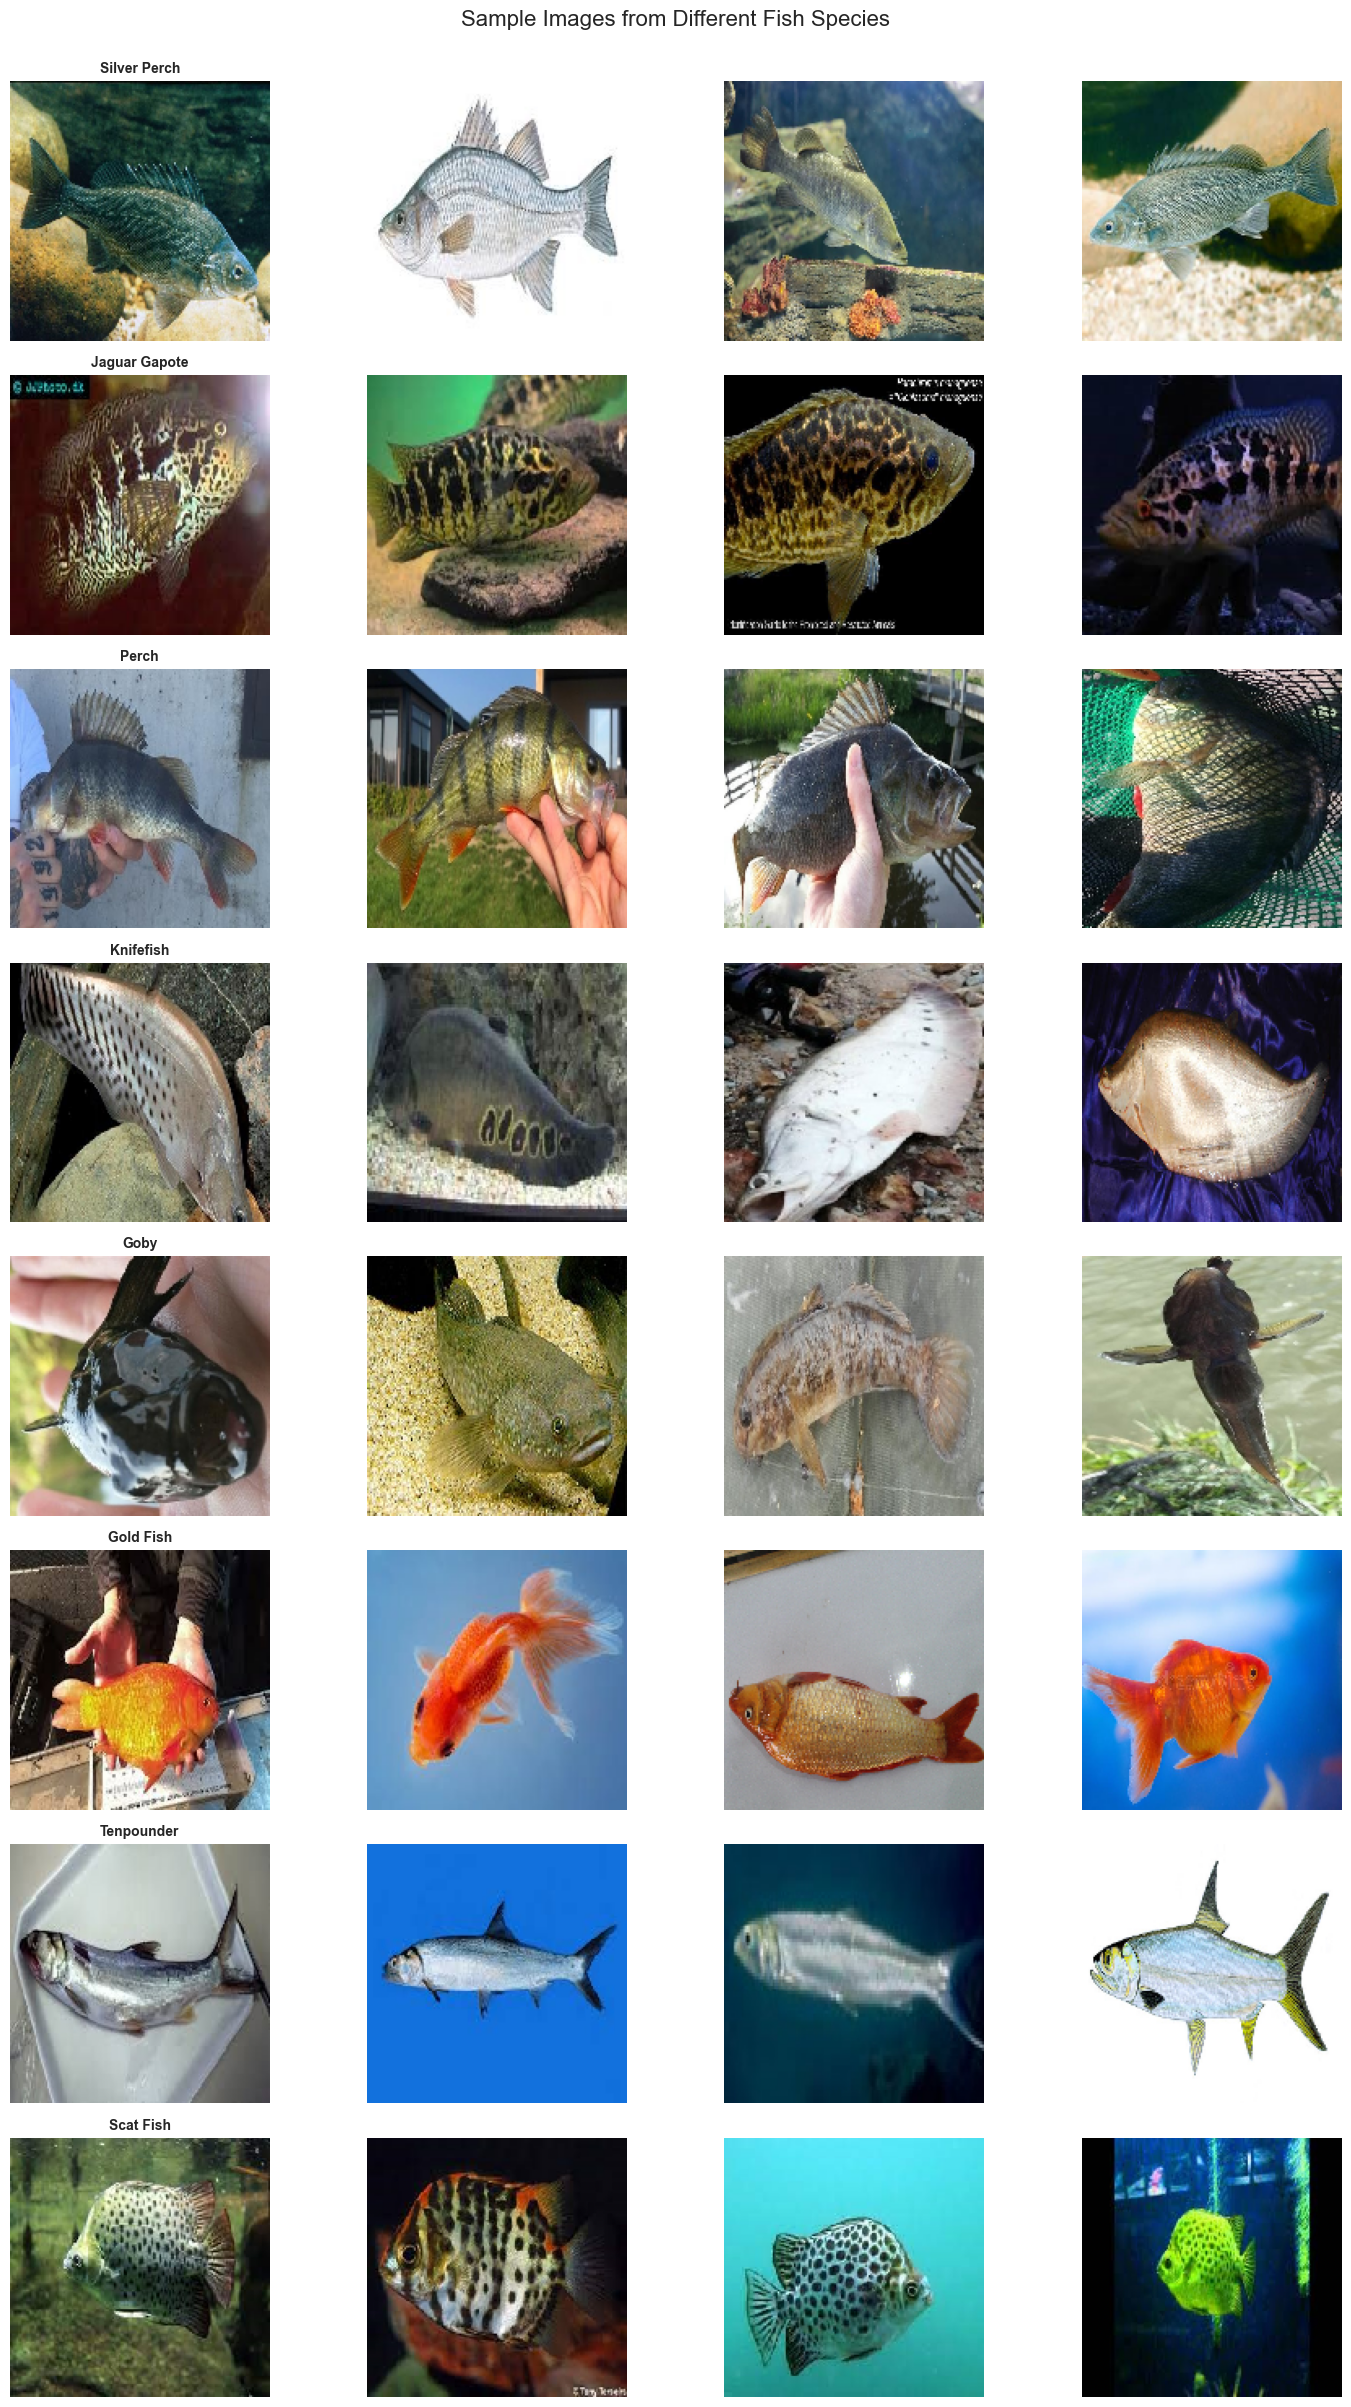

In [34]:
# Visualize sample images from different classes
def visualize_samples(directory, num_classes=8, images_per_class=4):
    """Display sample images from random classes."""
    # Select random classes
    selected_classes = np.random.choice(CLASS_NAMES, size=min(num_classes, len(CLASS_NAMES)), replace=False)
    
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(15, 3*num_classes))
    fig.suptitle('Sample Images from Different Fish Species', fontsize=16, y=1.001)
    
    for i, class_name in enumerate(selected_classes):
        class_path = directory / class_name
        # Get all image files (use set to avoid duplicates on Windows)
        image_files = list(set(
            list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG')) +
            list(class_path.glob('*.jpeg')) + list(class_path.glob('*.JPEG')) +
            list(class_path.glob('*.png')) + list(class_path.glob('*.PNG')) +
            list(class_path.glob('*.gif')) + list(class_path.glob('*.GIF')) +
            list(class_path.glob('*.webp')) + list(class_path.glob('*.WEBP'))
        ))
        
        # Select random images
        selected_images = np.random.choice(image_files, size=min(images_per_class, len(image_files)), replace=False)
        
        for j, img_path in enumerate(selected_images):
            img = load_img(img_path, target_size=IMG_SIZE)
            
            if num_classes == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name, fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Display samples from training set
visualize_samples(TRAIN_DIR, num_classes=8, images_per_class=4)

## 5. Analyze Class Distribution

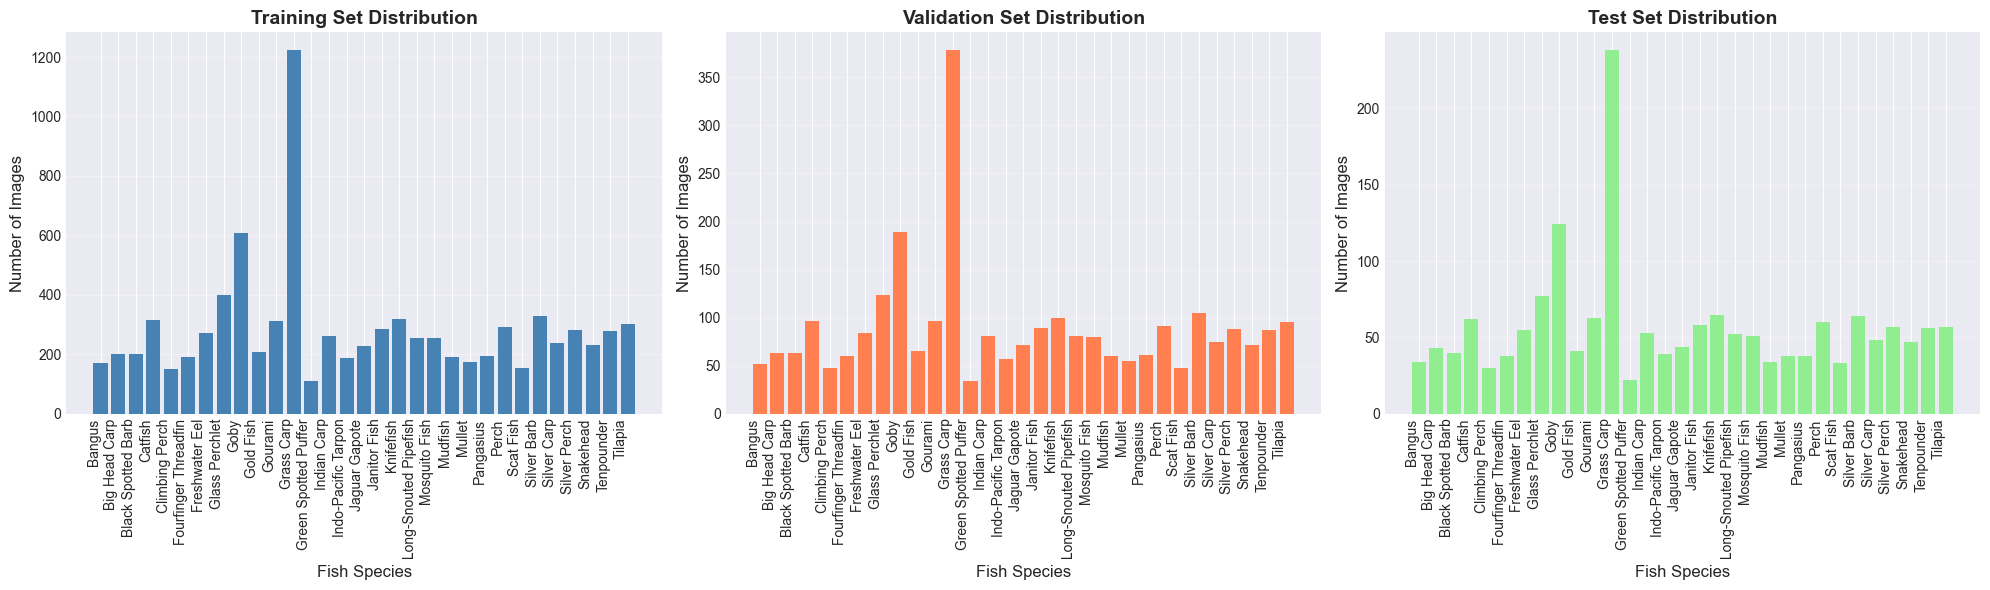


Class Imbalance Analysis (Training Set):
Min samples: 110 (Green Spotted Puffer)
Max samples: 1222 (Grass Carp)
Imbalance ratio: 11.11x


In [35]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Training set distribution
axes[0].bar(range(len(CLASS_NAMES)), summary_df['Train'], color='steelblue')
axes[0].set_xlabel('Fish Species', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(CLASS_NAMES)))
axes[0].set_xticklabels(CLASS_NAMES, rotation=90, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Validation set distribution
axes[1].bar(range(len(CLASS_NAMES)), summary_df['Validation'], color='coral')
axes[1].set_xlabel('Fish Species', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Validation Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(CLASS_NAMES)))
axes[1].set_xticklabels(CLASS_NAMES, rotation=90, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Test set distribution
axes[2].bar(range(len(CLASS_NAMES)), summary_df['Test'], color='lightgreen')
axes[2].set_xlabel('Fish Species', fontsize=12)
axes[2].set_ylabel('Number of Images', fontsize=12)
axes[2].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(CLASS_NAMES)))
axes[2].set_xticklabels(CLASS_NAMES, rotation=90, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identify class imbalance
print("\nClass Imbalance Analysis (Training Set):")
print(f"Min samples: {summary_df['Train'].min()} ({summary_df.loc[summary_df['Train'].idxmin(), 'Class']})")
print(f"Max samples: {summary_df['Train'].max()} ({summary_df.loc[summary_df['Train'].idxmax(), 'Class']})")
print(f"Imbalance ratio: {summary_df['Train'].max() / summary_df['Train'].min():.2f}x")

## 6. Data Preprocessing and Augmentation

In [36]:
# Data augmentation for training set (Optimized - reduced transformations)
train_datagen = ImageDataGenerator(
    rescale=1./255,                    # Normalize pixel values to [0,1]
    rotation_range=20,                 # Reduced from 30
    width_shift_range=0.1,             # Reduced from 0.2
    height_shift_range=0.1,            # Reduced from 0.2
    zoom_range=0.15,                   # Reduced from 0.2
    horizontal_flip=True,              # Keep horizontal flip
    fill_mode='nearest'                # Fill strategy for new pixels
)

# Only rescaling for validation and test sets (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Data augmentation configured successfully!")
print("\nTraining augmentation:")
print("- Rescaling: 1/255")
print("- Rotation: ±30°")
print("- Width/Height shift: 20%")
print("- Shear: 20%")
print("- Zoom: 20%")
print("- Horizontal flip: Yes")
print("\nValidation/Test: Rescaling only")

Data augmentation configured successfully!

Training augmentation:
- Rescaling: 1/255
- Rotation: ±30°
- Width/Height shift: 20%
- Shear: 20%
- Zoom: 20%
- Horizontal flip: Yes

Validation/Test: Rescaling only


## 7. Create Data Generators

In [37]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"\nNumber of batches per epoch:")
print(f"Training: {len(train_generator)}")
print(f"Validation: {len(val_generator)}")
print(f"Test: {len(test_generator)}")

Found 8819 images belonging to 31 classes.
Found 2751 images belonging to 31 classes.
Found 1761 images belonging to 31 classes.

Training samples: 8819
Validation samples: 2751
Test samples: 1761

Number of batches per epoch:
Training: 138
Validation: 43
Test: 28


## 8. Handle Class Imbalance

In [38]:
# Calculate class weights to handle imbalance
class_indices = train_generator.class_indices
class_labels = np.array([class_indices[name] for name in CLASS_NAMES])

# Get training labels
train_labels = train_generator.classes

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Create dictionary for Keras
class_weights = dict(enumerate(class_weights_array))

print("Class weights computed to handle imbalance:")
print("\nTop 5 highest weights (underrepresented classes):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)[:5]
for idx, weight in sorted_weights:
    class_name = list(class_indices.keys())[list(class_indices.values()).index(idx)]
    print(f"{class_name}: {weight:.3f}")

print("\nTop 5 lowest weights (overrepresented classes):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1])[:5]
for idx, weight in sorted_weights:
    class_name = list(class_indices.keys())[list(class_indices.values()).index(idx)]
    print(f"{class_name}: {weight:.3f}")

Class weights computed to handle imbalance:

Top 5 highest weights (underrepresented classes):
Green Spotted Puffer: 2.586
Climbing Perch: 1.872
Scat Fish: 1.847
Bangus: 1.664
Mullet: 1.635

Top 5 lowest weights (overrepresented classes):
Grass Carp: 0.233
Goby: 0.469
Glass Perchlet: 0.713
Silver Barb: 0.865
Knifefish: 0.892


## 9. Build Custom CNN Model from Scratch

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=31):

    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Classification head (Simplified)
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the model
model_custom = build_custom_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES)

# Display model architecture
model_custom.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 160, 160, 32)      896       
                                                                 
 batch_normalization_4 (Batc  (None, 160, 160, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 80, 80, 32)       0         
 2D)                                                             
                                                                 
 dropout_4 (Dropout)         (None, 80, 80, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 80, 80, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 80, 80, 64)      

## 10. Compile the Custom CNN Model

In [40]:
# Compile the model
model_custom.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

print("Model compiled successfully!")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Categorical Crossentropy")
print(f"Metrics: Accuracy, Top-5 Accuracy")

Model compiled successfully!
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy
Metrics: Accuracy, Top-5 Accuracy


## 11. Train the Custom CNN Model

In [41]:
# Define callbacks (with periodic checkpoints)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # Increased patience for 100 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_custom_cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoint_custom_cnn_epoch_{epoch:02d}.h5',
        save_freq='epoch',
        period=20,  # Save every 20 epochs
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("Starting training...")
history_custom = model_custom.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting training...
Epoch 1/100
138/138 [==============================] - ETA: 0s - loss: 3.5537 - accuracy: 0.1241 - top5_accuracy: 0.3710
Epoch 1: val_accuracy improved from -inf to 0.03962, saving model to best_custom_cnn_model.h5
138/138 [==============================] - 518s 4s/step - loss: 3.5537 - accuracy: 0.1241 - top5_accuracy: 0.3710 - val_loss: 3.6887 - val_accuracy: 0.0396 - val_top5_accuracy: 0.2664 - lr: 0.0010
Epoch 2/100
138/138 [==============================] - ETA: 0s - loss: 3.1661 - accuracy: 0.1663 - top5_accuracy: 0.4675
Epoch 2: val_accuracy improved from 0.03962 to 0.06398, saving model to best_custom_cnn_model.h5
138/138 [==============================] - 429s 3s/step - loss: 3.1661 - accuracy: 0.1663 - top5_accuracy: 0.4675 - val_loss: 5.6783 - val_accuracy: 0.0640 - val_top5_accuracy: 0.2995 - lr: 0.0010
Epoch 3/100
138/138 [==============================] - ETA: 0s - loss: 2.9723 - accuracy: 0.2035 - top5_accuracy: 0.5082
Epoch 3: val_accuracy did not i

## 12. Visualize Training History (Custom CNN)

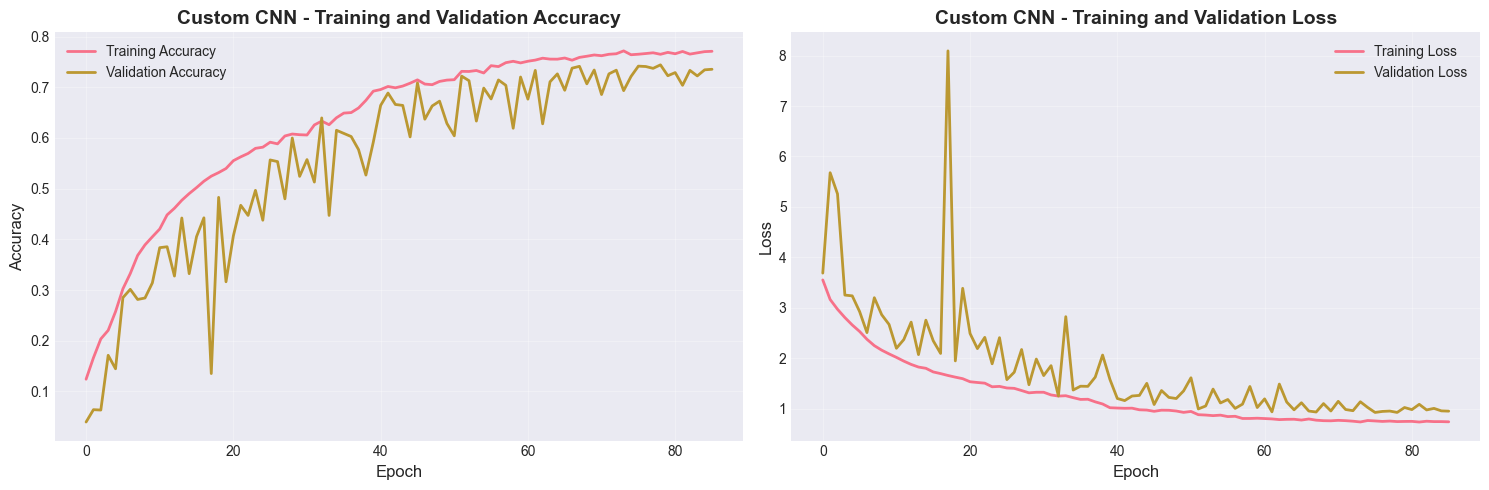


Final Training Accuracy: 0.7708
Final Validation Accuracy: 0.7354
Final Training Loss: 0.7414
Final Validation Loss: 0.9527


In [42]:
# Plot training history
def plot_training_history(history, title_prefix=""):
    """Plot training and validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title(f'{title_prefix}Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title(f'{title_prefix}Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot custom CNN training history
plot_training_history(history_custom, "Custom CNN - ")

# Print final metrics
final_train_acc = history_custom.history['accuracy'][-1]
final_val_acc = history_custom.history['val_accuracy'][-1]
final_train_loss = history_custom.history['loss'][-1]
final_val_loss = history_custom.history['val_loss'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

## 13. Evaluate Custom CNN on Test Set

In [43]:
# Evaluate on test set
print("Evaluating custom CNN on test set...")
test_loss, test_accuracy, test_top5_accuracy = model_custom.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"Custom CNN Test Results:")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Top-5 Accuracy: {test_top5_accuracy:.4f} ({test_top5_accuracy*100:.2f}%)")
print(f"{'='*50}")

Evaluating custom CNN on test set...
28/28 [==============================] - 30s 1s/step - loss: 0.9302 - accuracy: 0.7445 - top5_accuracy: 0.9409

Custom CNN Test Results:
Test Loss: 0.9302
Test Accuracy: 0.7445 (74.45%)
Test Top-5 Accuracy: 0.9409 (94.09%)


## 14. Generate Predictions and Confusion Matrix (Custom CNN)

Generating predictions on test set...
28/28 [==============================] - 16s 551ms/step


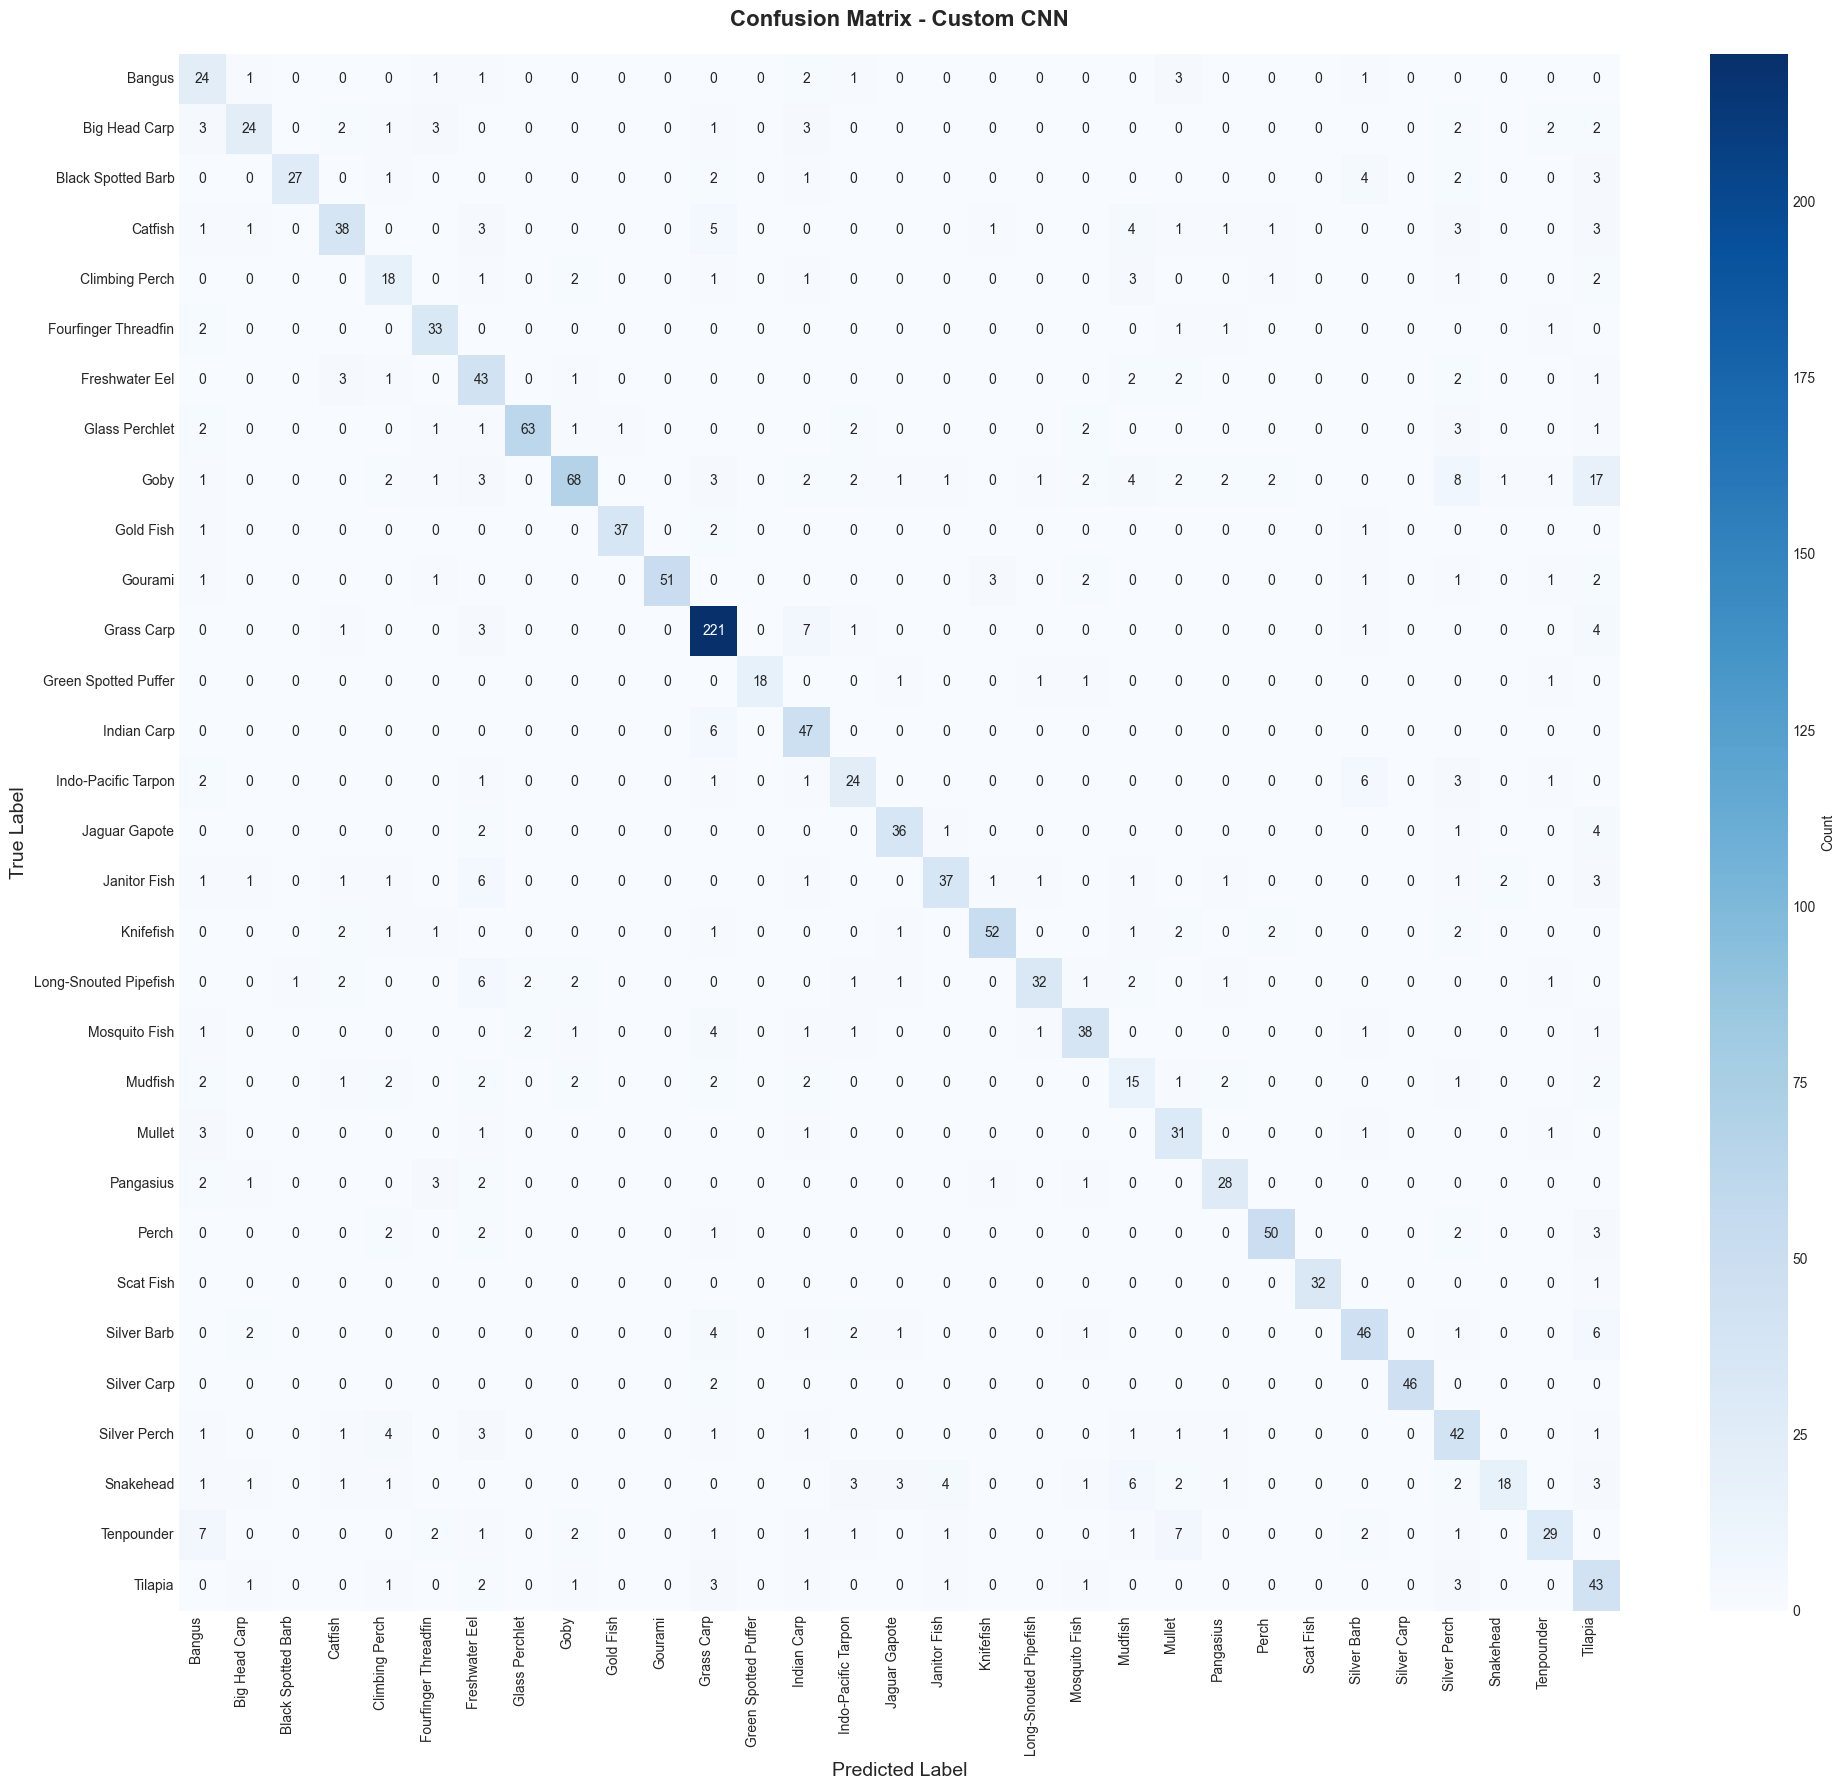


Confusion matrix shape: (31, 31)


In [44]:
# Generate predictions
print("Generating predictions on test set...")
test_generator.reset()
predictions_custom = model_custom.predict(test_generator, verbose=1)
predicted_classes_custom = np.argmax(predictions_custom, axis=1)
true_classes = test_generator.classes

# Generate confusion matrix
cm_custom = confusion_matrix(true_classes, predicted_classes_custom)

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - Custom CNN', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nConfusion matrix shape: {cm_custom.shape}")

## 15. Classification Report (Custom CNN)

In [45]:
# Generate classification report
print("Classification Report - Custom CNN:")
print("="*80)
report_custom = classification_report(true_classes, predicted_classes_custom, 
                                     target_names=CLASS_NAMES, digits=4)
print(report_custom)

# Convert to dataframe for better visualization
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_classes, predicted_classes_custom, labels=range(NUM_CLASSES)
)

report_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Class Performance Summary:")
print(report_df.to_string(index=False))

# Identify best and worst performing classes
print(f"\nBest performing class (F1): {report_df.loc[report_df['F1-Score'].idxmax(), 'Class']} ({report_df['F1-Score'].max():.4f})")
print(f"Worst performing class (F1): {report_df.loc[report_df['F1-Score'].idxmin(), 'Class']} ({report_df['F1-Score'].min():.4f})")

Classification Report - Custom CNN:
                       precision    recall  f1-score   support

               Bangus     0.4364    0.7059    0.5393        34
        Big Head Carp     0.7500    0.5581    0.6400        43
   Black Spotted Barb     0.9643    0.6750    0.7941        40
              Catfish     0.7308    0.6129    0.6667        62
       Climbing Perch     0.5143    0.6000    0.5538        30
 Fourfinger Threadfin     0.7174    0.8684    0.7857        38
       Freshwater Eel     0.5181    0.7818    0.6232        55
       Glass Perchlet     0.9403    0.8182    0.8750        77
                 Goby     0.8500    0.5484    0.6667       124
            Gold Fish     0.9737    0.9024    0.9367        41
              Gourami     1.0000    0.8095    0.8947        63
           Grass Carp     0.8467    0.9286    0.8858       238
 Green Spotted Puffer     1.0000    0.8182    0.9000        22
          Indian Carp     0.6438    0.8868    0.7460        53
  Indo-Pacific Tar

## 16. Transfer Learning with Pre-trained Models

Now let's build models using transfer learning with popular pre-trained architectures.

In [46]:
def build_transfer_learning_model(base_model_name='VGG16', input_shape=(224, 224, 3), num_classes=31, trainable_layers=0):
    """
    Build a transfer learning model using pre-trained architecture.
    
    Args:
        base_model_name: Name of the pre-trained model ('VGG16', 'ResNet50', 'MobileNetV2')
        input_shape: Input image shape
        num_classes: Number of output classes
        trainable_layers: Number of top layers to unfreeze for fine-tuning (0 = freeze all)
    """
    # Load pre-trained base model
    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unknown model: {base_model_name}")
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Optionally unfreeze top layers for fine-tuning
    if trainable_layers > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
    
    # Build model with custom classification head
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build MobileNetV2 model (lightweight and efficient)
print("Building MobileNetV2 transfer learning model...")
model_mobilenet = build_transfer_learning_model('MobileNetV2', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES)

# Display model summary
model_mobilenet.summary()

# Count trainable vs non-trainable parameters
trainable_params = np.sum([np.prod(v.get_shape()) for v in model_mobilenet.trainable_weights])
non_trainable_params = np.sum([np.prod(v.get_shape()) for v in model_mobilenet.non_trainable_weights])
print(f"\nTrainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters: {trainable_params + non_trainable_params:,}")

Building MobileNetV2 transfer learning model...
9406464/9406464 [==============================] - 2s 0us/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 512)               655872    
                                                                 
 batch_normalization_8 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dropout_

## 17. Compile and Train Transfer Learning Model

In [47]:
# Compile the transfer learning model
model_mobilenet.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

# Define callbacks for transfer learning model (with periodic checkpoints)
callbacks_tl = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # Increased patience for 100 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mobilenet_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoint_mobilenet_epoch_{epoch:02d}.h5',
        save_freq='epoch',
        period=20,  # Save every 20 epochs
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("Starting training of MobileNetV2 model...")
history_mobilenet = model_mobilenet.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_tl,
    verbose=1
)

print("\nMobileNetV2 training completed!")

Starting training of MobileNetV2 model...
Epoch 1/100
138/138 [==============================] - ETA: 0s - loss: 2.0107 - accuracy: 0.4527 - top5_accuracy: 0.7500
Epoch 1: val_accuracy improved from -inf to 0.70593, saving model to best_mobilenet_model.h5
138/138 [==============================] - 164s 1s/step - loss: 2.0107 - accuracy: 0.4527 - top5_accuracy: 0.7500 - val_loss: 0.9792 - val_accuracy: 0.7059 - val_top5_accuracy: 0.9458 - lr: 0.0010
Epoch 2/100
138/138 [==============================] - ETA: 0s - loss: 1.1288 - accuracy: 0.6671 - top5_accuracy: 0.9145
Epoch 2: val_accuracy improved from 0.70593 to 0.78808, saving model to best_mobilenet_model.h5
138/138 [==============================] - 155s 1s/step - loss: 1.1288 - accuracy: 0.6671 - top5_accuracy: 0.9145 - val_loss: 0.7135 - val_accuracy: 0.7881 - val_top5_accuracy: 0.9618 - lr: 0.0010
Epoch 3/100
138/138 [==============================] - ETA: 0s - loss: 0.9432 - accuracy: 0.7139 - top5_accuracy: 0.9390
Epoch 3: val

## 18. Visualize Training History (Transfer Learning)

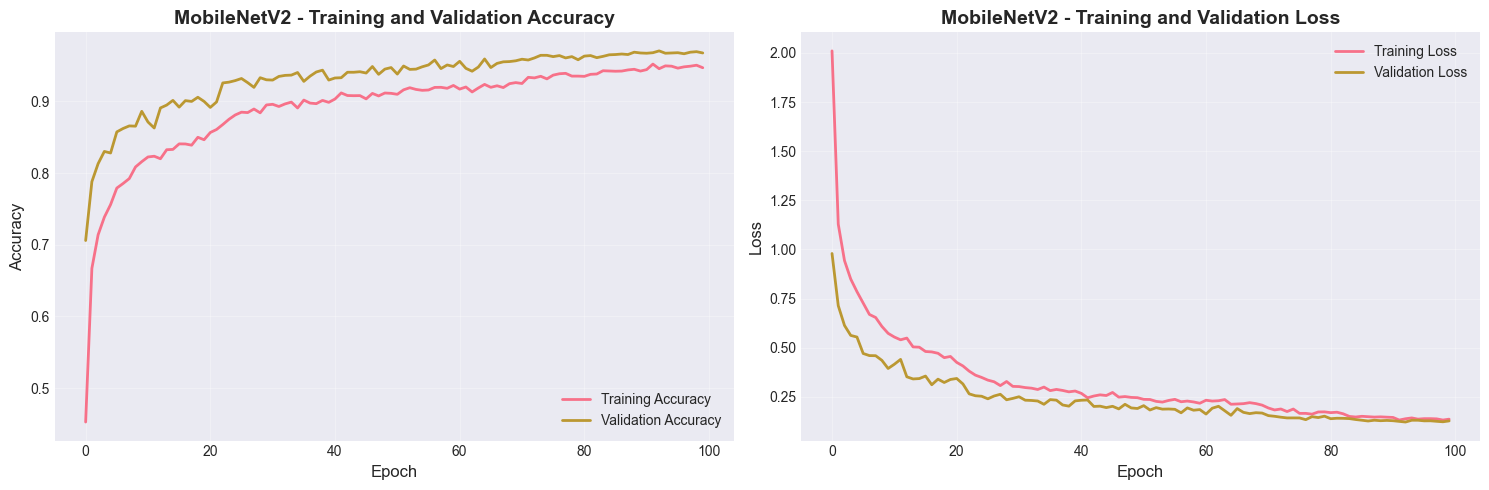


Final Training Accuracy: 0.9470
Final Validation Accuracy: 0.9676
Final Training Loss: 0.1358
Final Validation Loss: 0.1270


In [48]:
# Plot MobileNetV2 training history
plot_training_history(history_mobilenet, "MobileNetV2 - ")

# Print final metrics
final_train_acc_mb = history_mobilenet.history['accuracy'][-1]
final_val_acc_mb = history_mobilenet.history['val_accuracy'][-1]
final_train_loss_mb = history_mobilenet.history['loss'][-1]
final_val_loss_mb = history_mobilenet.history['val_loss'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc_mb:.4f}")
print(f"Final Validation Accuracy: {final_val_acc_mb:.4f}")
print(f"Final Training Loss: {final_train_loss_mb:.4f}")
print(f"Final Validation Loss: {final_val_loss_mb:.4f}")

## 19. Evaluate Transfer Learning Model

Evaluating MobileNetV2 on test set...
28/28 [==============================] - 41s 1s/step - loss: 0.1861 - accuracy: 0.9483 - top5_accuracy: 0.9955

MobileNetV2 Test Results:
Test Loss: 0.1861
Test Accuracy: 0.9483 (94.83%)
Test Top-5 Accuracy: 0.9955 (99.55%)
28/28 [==============================] - 23s 774ms/step


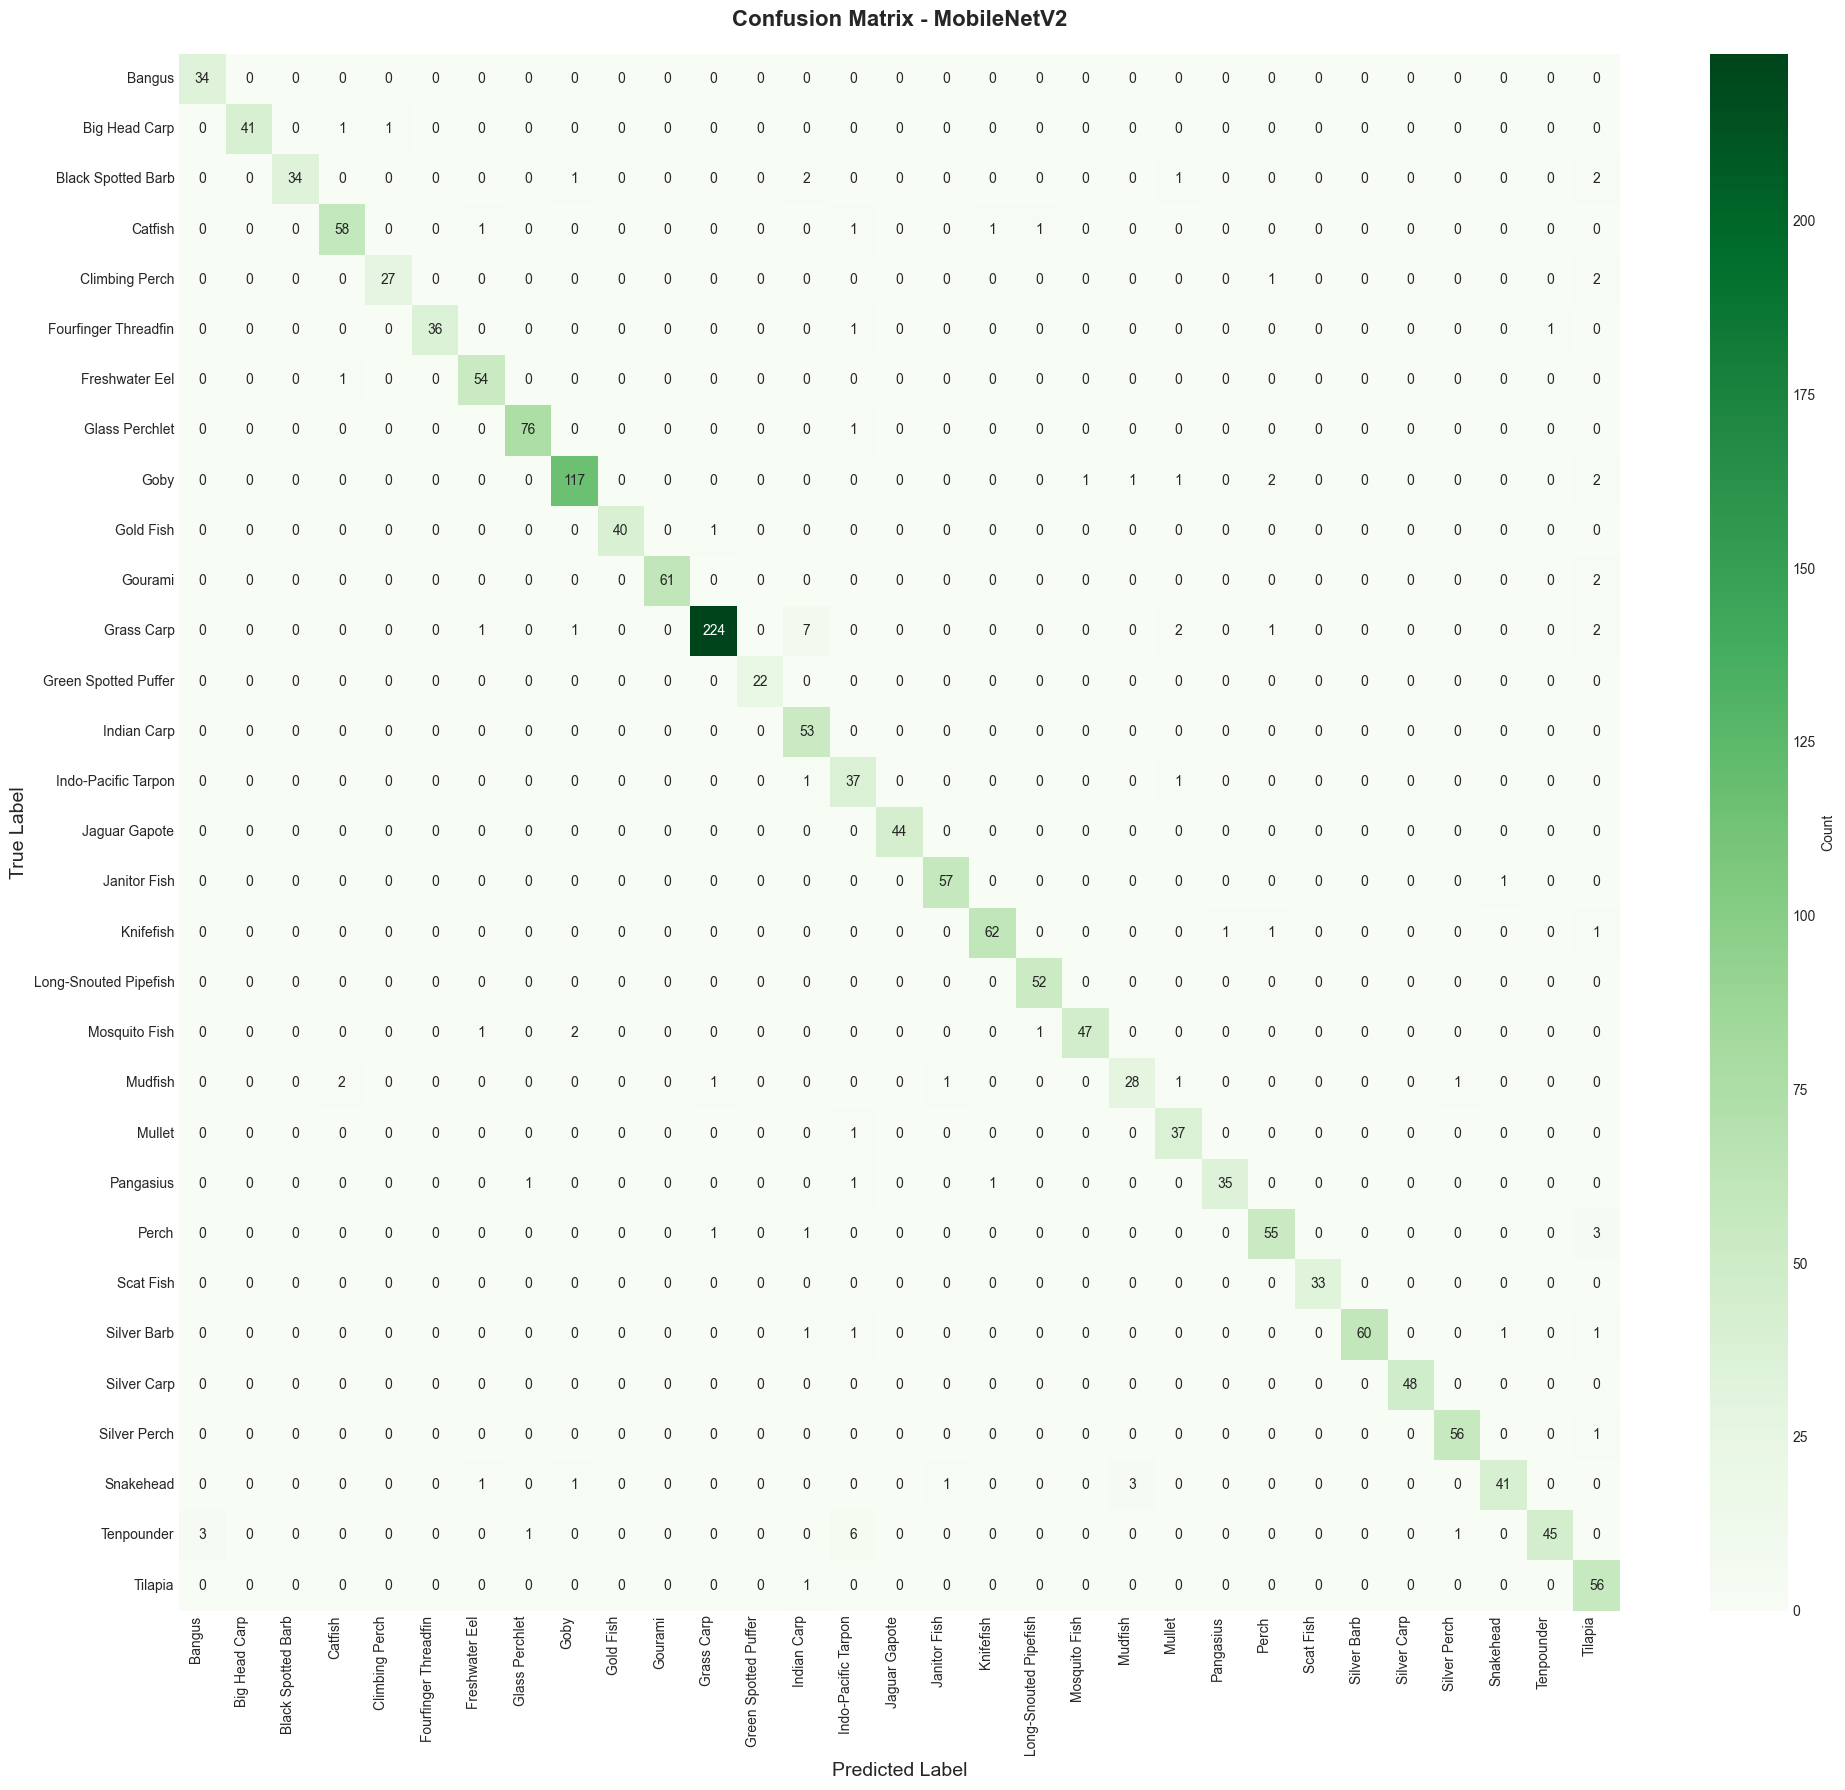

In [49]:
# Evaluate MobileNetV2 on test set
print("Evaluating MobileNetV2 on test set...")
test_loss_mb, test_accuracy_mb, test_top5_accuracy_mb = model_mobilenet.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"MobileNetV2 Test Results:")
print(f"{'='*50}")
print(f"Test Loss: {test_loss_mb:.4f}")
print(f"Test Accuracy: {test_accuracy_mb:.4f} ({test_accuracy_mb*100:.2f}%)")
print(f"Test Top-5 Accuracy: {test_top5_accuracy_mb:.4f} ({test_top5_accuracy_mb*100:.2f}%)")
print(f"{'='*50}")

# Generate predictions
test_generator.reset()
predictions_mobilenet = model_mobilenet.predict(test_generator, verbose=1)
predicted_classes_mobilenet = np.argmax(predictions_mobilenet, axis=1)

# Generate confusion matrix
cm_mobilenet = confusion_matrix(true_classes, predicted_classes_mobilenet)

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - MobileNetV2', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 20. Classification Report (Transfer Learning)

In [50]:
# Generate classification report for MobileNetV2
print("Classification Report - MobileNetV2:")
print("="*80)
report_mobilenet = classification_report(true_classes, predicted_classes_mobilenet, 
                                        target_names=CLASS_NAMES, digits=4)
print(report_mobilenet)

Classification Report - MobileNetV2:
                       precision    recall  f1-score   support

               Bangus     0.9189    1.0000    0.9577        34
        Big Head Carp     1.0000    0.9535    0.9762        43
   Black Spotted Barb     1.0000    0.8500    0.9189        40
              Catfish     0.9355    0.9355    0.9355        62
       Climbing Perch     0.9643    0.9000    0.9310        30
 Fourfinger Threadfin     1.0000    0.9474    0.9730        38
       Freshwater Eel     0.9310    0.9818    0.9558        55
       Glass Perchlet     0.9744    0.9870    0.9806        77
                 Goby     0.9590    0.9435    0.9512       124
            Gold Fish     1.0000    0.9756    0.9877        41
              Gourami     1.0000    0.9683    0.9839        63
           Grass Carp     0.9868    0.9412    0.9634       238
 Green Spotted Puffer     1.0000    1.0000    1.0000        22
          Indian Carp     0.8030    1.0000    0.8908        53
  Indo-Pacific Ta

## 21. Compare Model Performance


Model Performance Comparison:
      Model  Test Accuracy  Top-5 Accuracy  Test Loss
 Custom CNN       0.744463        0.940943   0.930222
MobileNetV2       0.948325        0.995457   0.186089


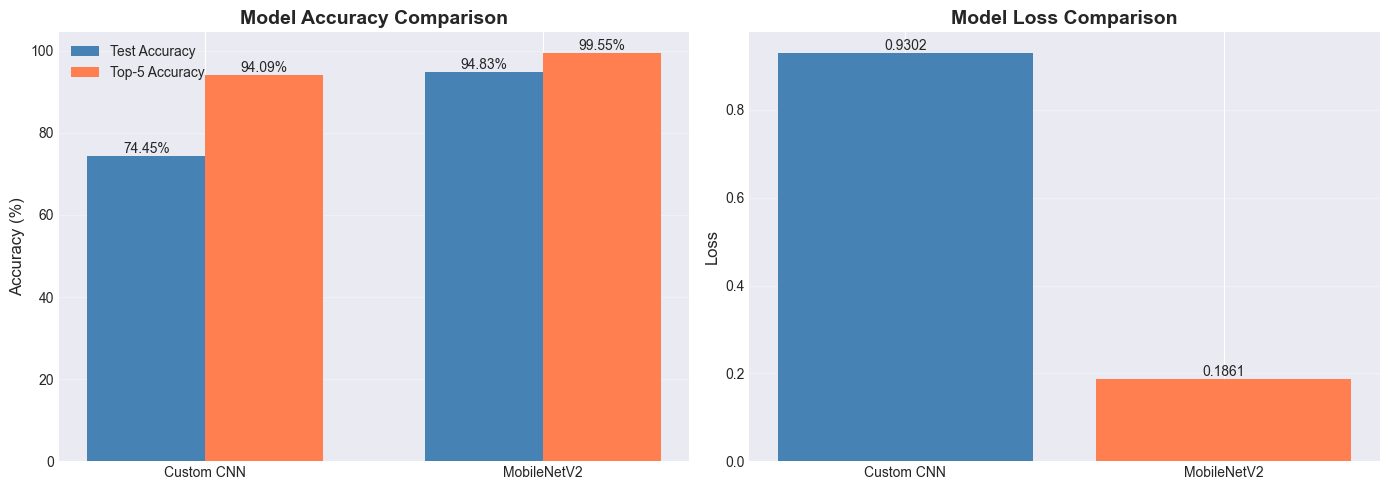


Best performing model: MobileNetV2


In [51]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2'],
    'Test Accuracy': [test_accuracy, test_accuracy_mb],
    'Top-5 Accuracy': [test_top5_accuracy, test_top5_accuracy_mb],
    'Test Loss': [test_loss, test_loss_mb]
})

print("\nModel Performance Comparison:")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Custom CNN', 'MobileNetV2']
accuracies = [test_accuracy * 100, test_accuracy_mb * 100]
top5_accuracies = [test_top5_accuracy * 100, test_top5_accuracy_mb * 100]

# Accuracy comparison
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width, label='Test Accuracy', color='steelblue')
bars2 = axes[0].bar(x + width/2, top5_accuracies, width, label='Top-5 Accuracy', color='coral')

axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Loss comparison
losses = [test_loss, test_loss_mb]
bars3 = axes[1].bar(models, losses, color=['steelblue', 'coral'])
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Determine best model
best_model = 'Custom CNN' if test_accuracy > test_accuracy_mb else 'MobileNetV2'
print(f"\nBest performing model: {best_model}")

## 22. Visualize CNN Feature Maps and Filters

Let's visualize what the CNN learns by examining convolutional filters and feature maps.

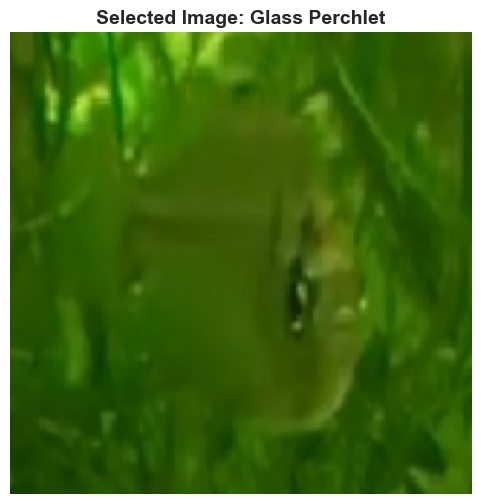

Image path: Dataset\test\Glass Perchlet\Picture371.jpg
True class: Glass Perchlet


In [52]:
# Select a random test image
test_images = list(set(
    list(TEST_DIR.glob('*/*.jpg')) + list(TEST_DIR.glob('*/*.JPG')) +
    list(TEST_DIR.glob('*/*.jpeg')) + list(TEST_DIR.glob('*/*.JPEG')) +
    list(TEST_DIR.glob('*/*.png')) + list(TEST_DIR.glob('*/*.PNG')) +
    list(TEST_DIR.glob('*/*.gif')) + list(TEST_DIR.glob('*/*.GIF')) +
    list(TEST_DIR.glob('*/*.webp')) + list(TEST_DIR.glob('*/*.WEBP'))
))
random_image_path = np.random.choice(test_images)

# Load and preprocess the image
img = load_img(random_image_path, target_size=IMG_SIZE)
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f'Selected Image: {random_image_path.parent.name}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print(f"Image path: {random_image_path}")
print(f"True class: {random_image_path.parent.name}")

Visualizing feature maps from Custom CNN:


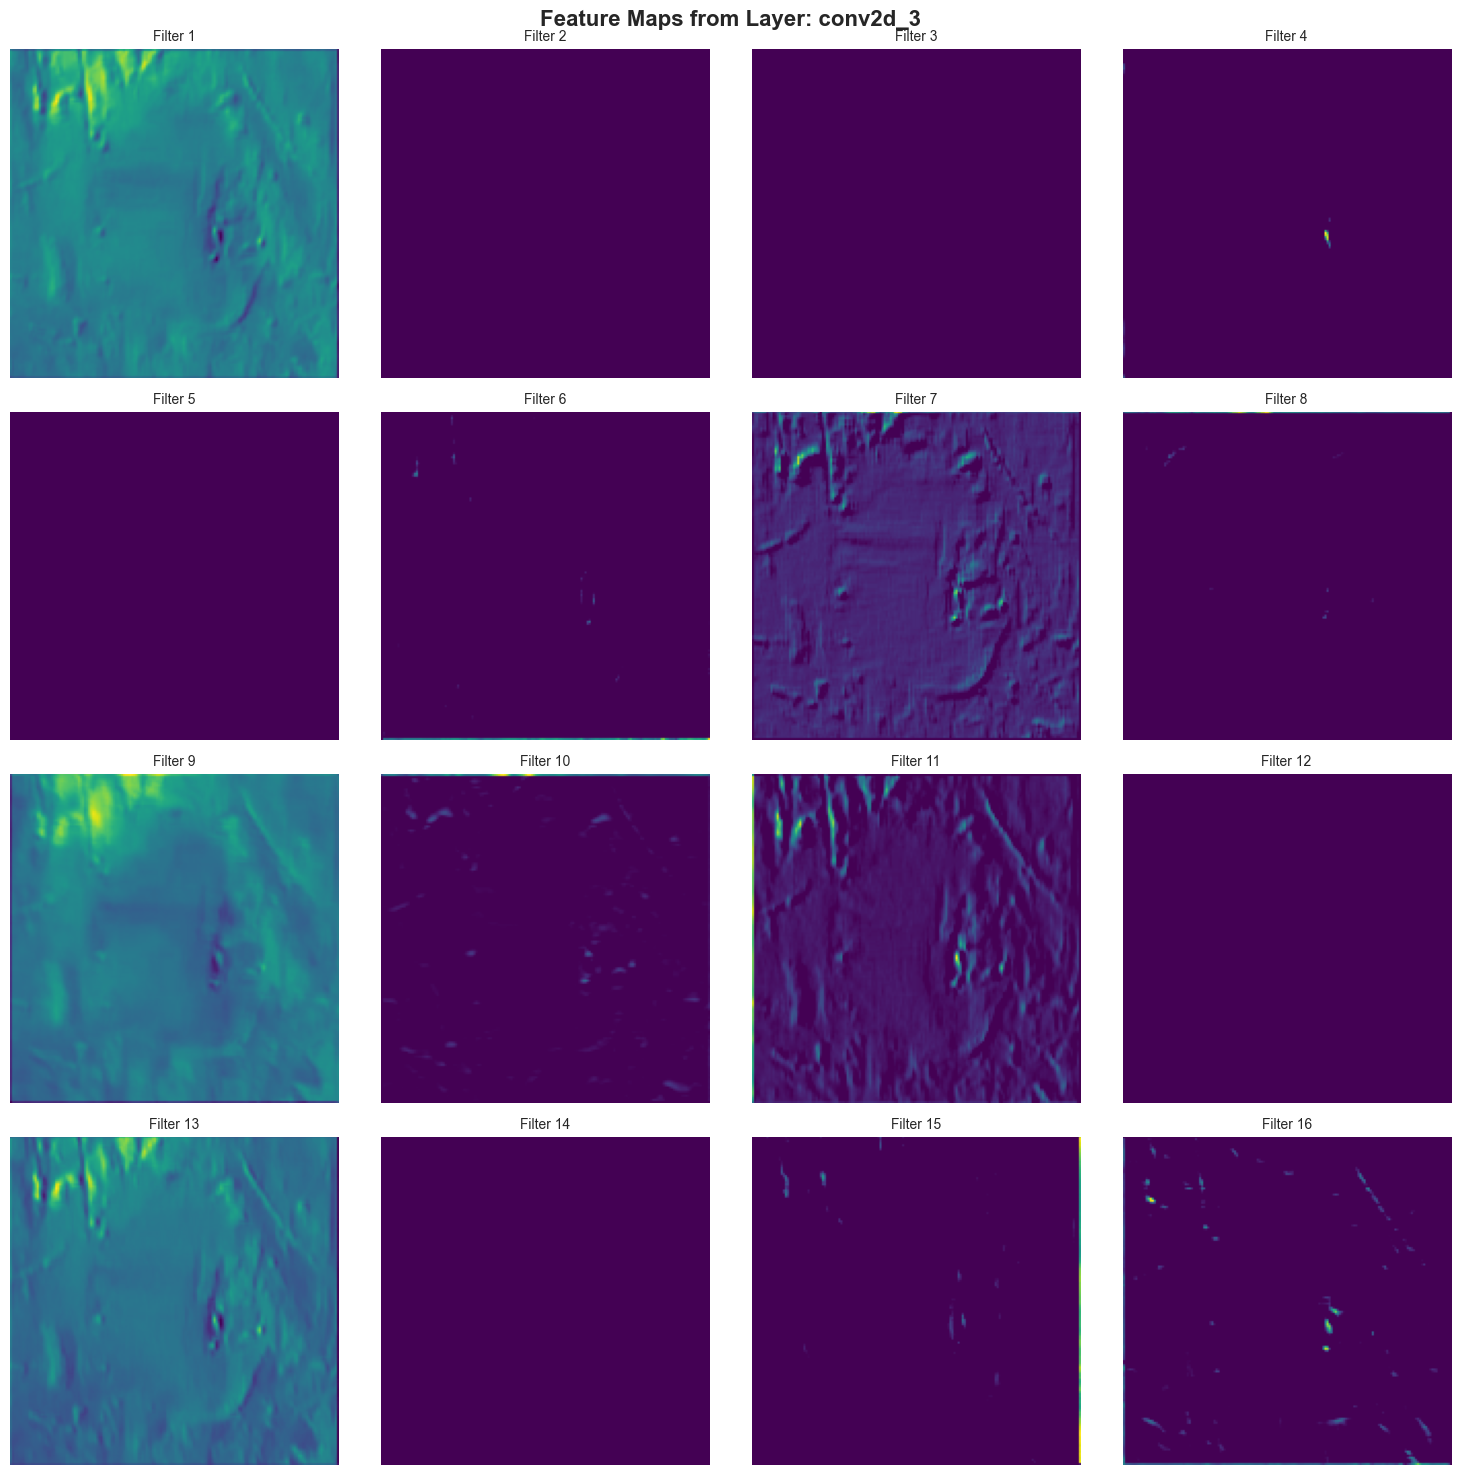

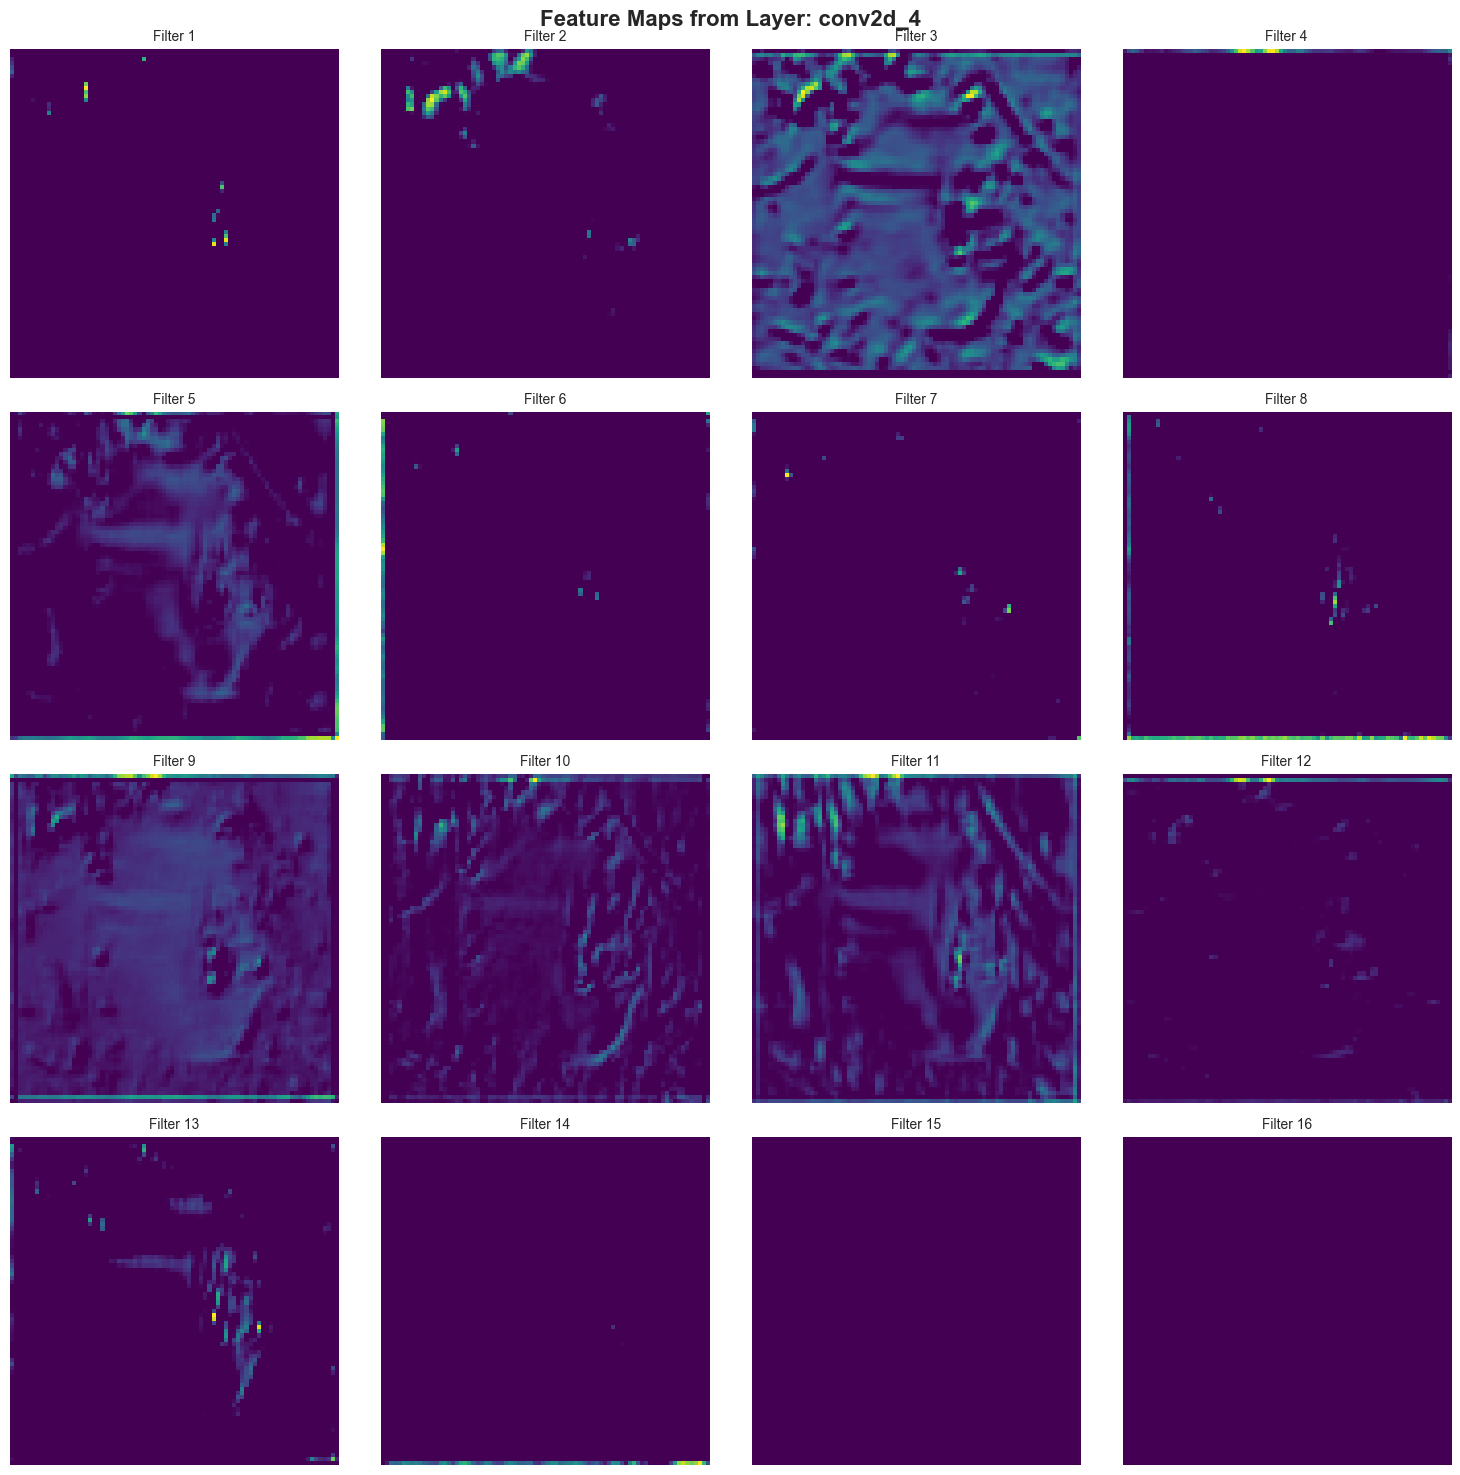

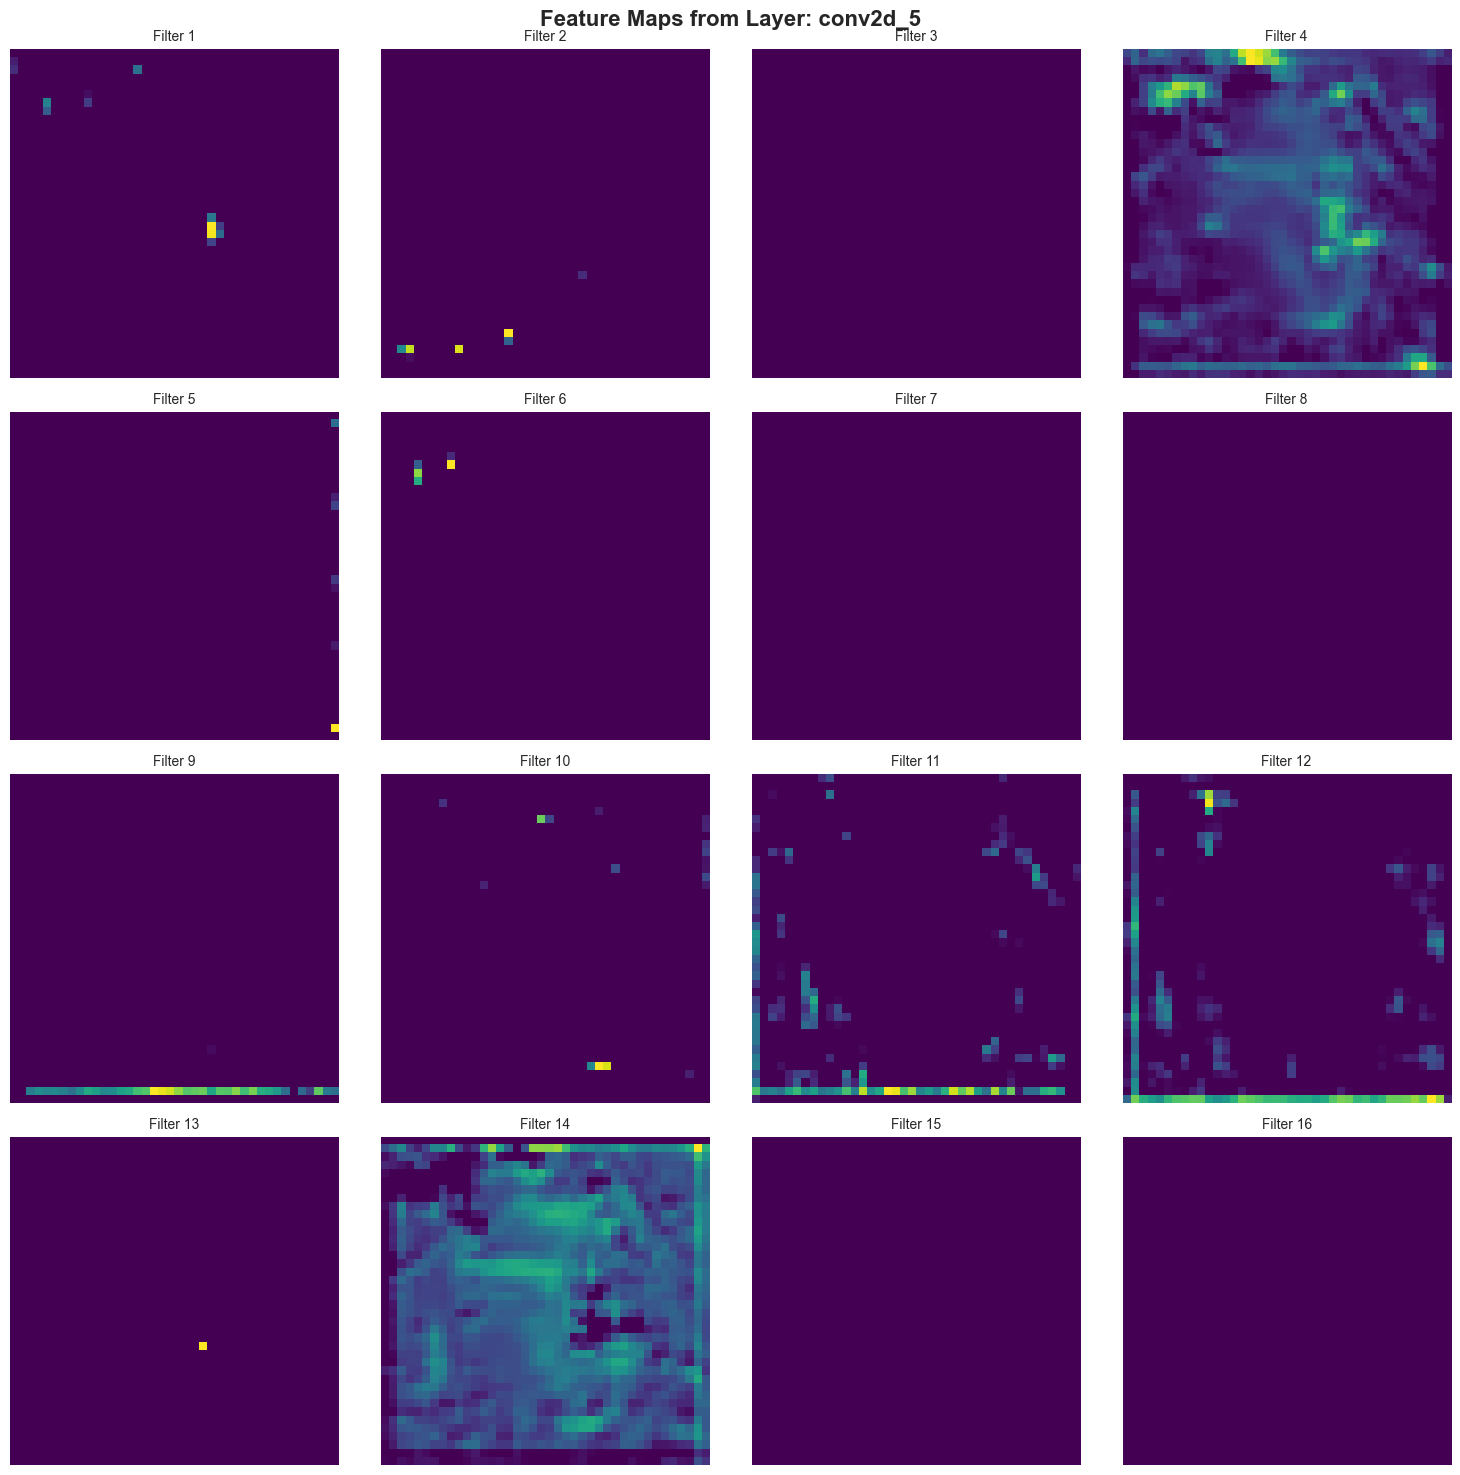

In [53]:
# Visualize feature maps from different convolutional layers
def visualize_feature_maps(model, img_array, layer_names=None, max_filters=16):
    """
    Visualize feature maps from convolutional layers.
    
    Args:
        model: Trained CNN model
        img_array: Preprocessed image array
        layer_names: List of layer names to visualize (None = auto-select Conv layers)
        max_filters: Maximum number of filters to display per layer
    """
    # Get convolutional layer names if not specified
    if layer_names is None:
        layer_names = [layer.name for layer in model.layers 
                      if 'conv' in layer.name.lower()][:4]  # First 4 conv layers
    
    # Create intermediate models for each layer
    for layer_name in layer_names:
        try:
            # Create model that outputs the feature map
            intermediate_model = Model(inputs=model.input,
                                      outputs=model.get_layer(layer_name).output)
            
            # Get feature maps
            feature_maps = intermediate_model.predict(img_array, verbose=0)
            
            # Number of filters to display
            n_filters = min(max_filters, feature_maps.shape[-1])
            
            # Calculate grid size
            grid_size = int(np.ceil(np.sqrt(n_filters)))
            
            # Plot feature maps
            fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
            fig.suptitle(f'Feature Maps from Layer: {layer_name}', fontsize=16, fontweight='bold')
            
            for i in range(grid_size * grid_size):
                row = i // grid_size
                col = i % grid_size
                ax = axes[row, col] if grid_size > 1 else axes
                
                if i < n_filters:
                    # Display feature map
                    feature_map = feature_maps[0, :, :, i]
                    ax.imshow(feature_map, cmap='viridis')
                    ax.set_title(f'Filter {i+1}', fontsize=10)
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Could not visualize layer {layer_name}: {str(e)}")

# Visualize feature maps from custom CNN
print("Visualizing feature maps from Custom CNN:")
visualize_feature_maps(model_custom, img_array)

## 23. Visualize Convolutional Filters

Visualizing filters from: conv2d_3


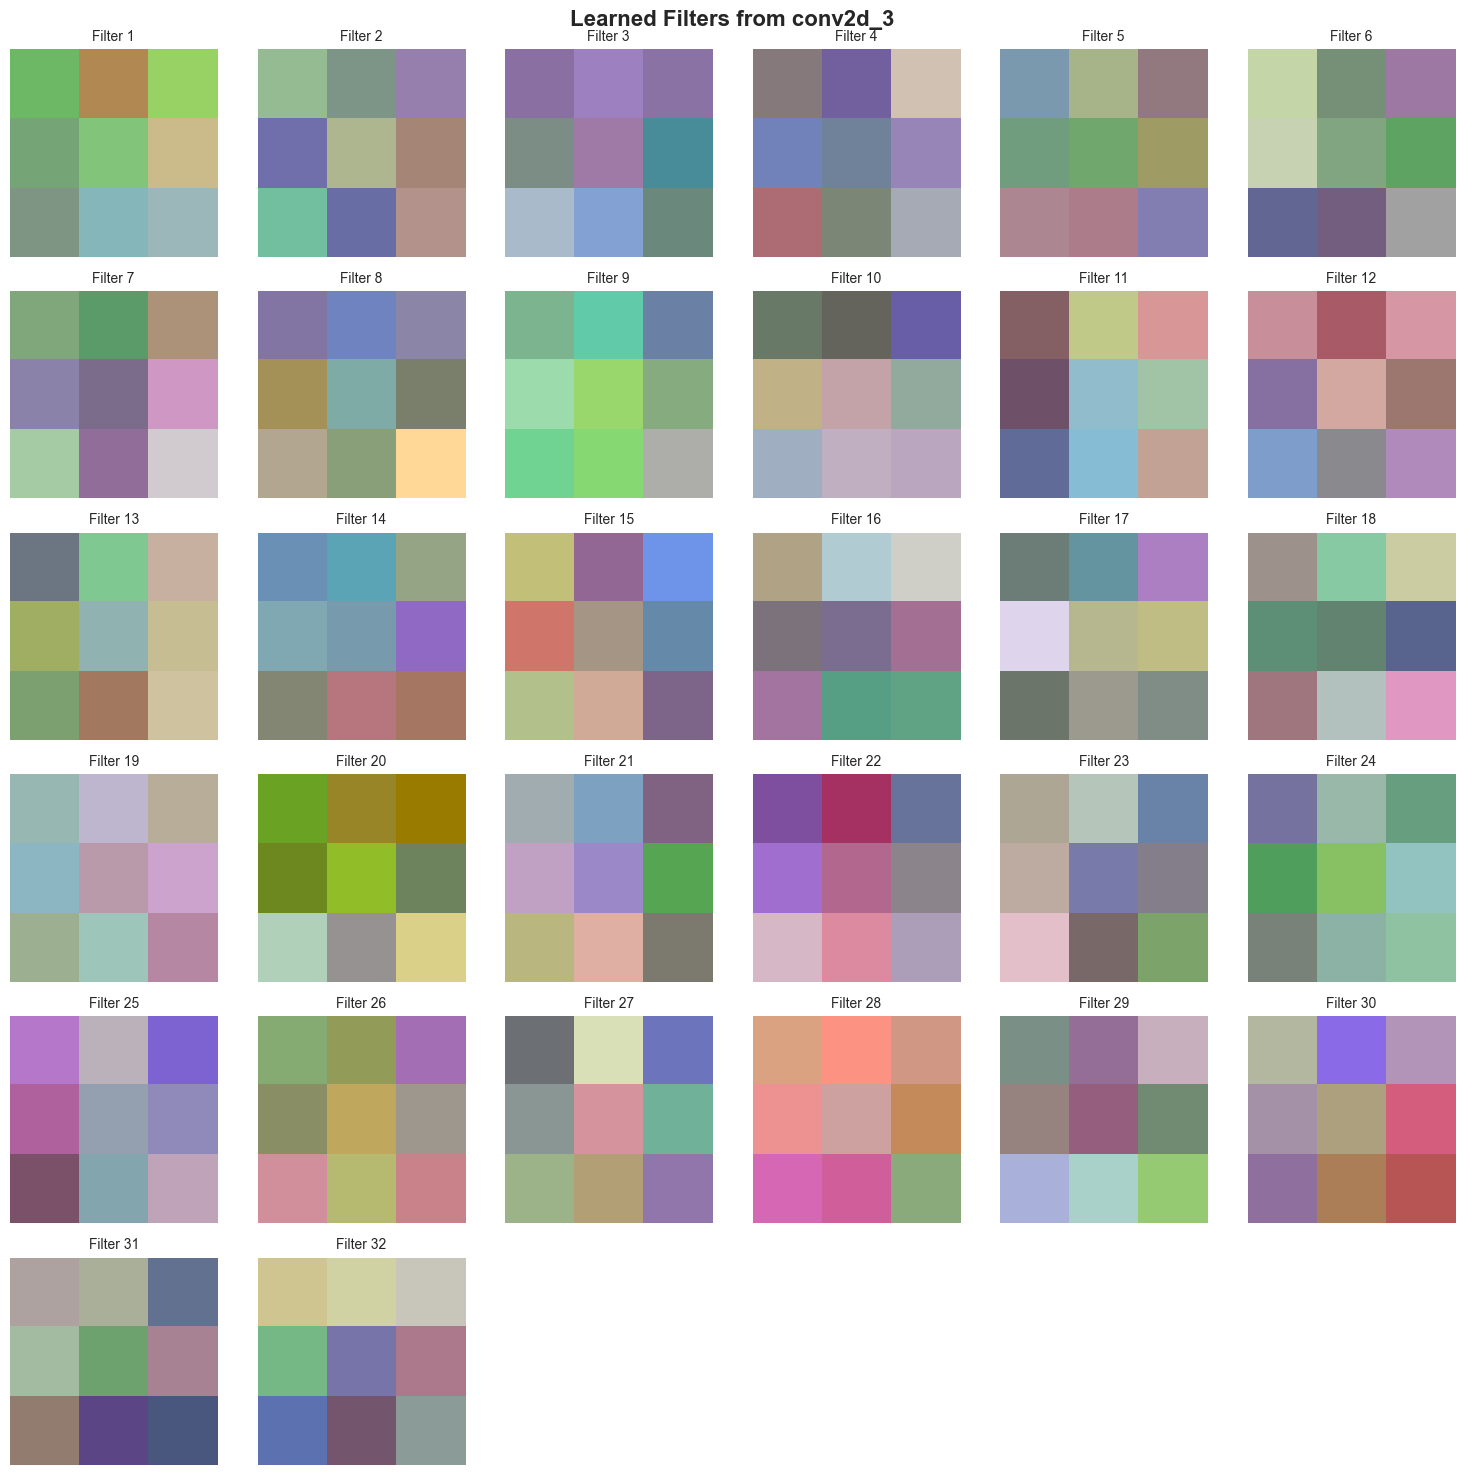

Filter shape: (3, 3, 3, 32)
Number of filters: 32


In [54]:
# Visualize learned filters from the first convolutional layer
def visualize_filters(model, layer_name, max_filters=32):
    """
    Visualize learned convolutional filters.
    
    Args:
        model: Trained CNN model
        layer_name: Name of the convolutional layer
        max_filters: Maximum number of filters to display
    """
    try:
        # Get layer weights
        layer = model.get_layer(layer_name)
        filters, biases = layer.get_weights()
        
        # Normalize filters to [0, 1]
        f_min, f_max = filters.min(), filters.max()
        filters = (filters - f_min) / (f_max - f_min)
        
        # Number of filters to display
        n_filters = min(max_filters, filters.shape[-1])
        
        # Calculate grid size
        grid_size = int(np.ceil(np.sqrt(n_filters)))
        
        # Plot filters
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
        fig.suptitle(f'Learned Filters from {layer_name}', fontsize=16, fontweight='bold')
        
        for i in range(grid_size * grid_size):
            row = i // grid_size
            col = i % grid_size
            ax = axes[row, col] if grid_size > 1 else axes
            
            if i < n_filters:
                # Get filter
                f = filters[:, :, :, i]
                
                # Normalize for display
                if f.shape[-1] == 1:
                    # Single channel - display as grayscale
                    ax.imshow(f[:, :, 0], cmap='gray')
                elif f.shape[-1] == 3:
                    # RGB channels
                    ax.imshow(f)
                else:
                    # Multiple channels - display first channel
                    ax.imshow(f[:, :, 0], cmap='viridis')
                
                ax.set_title(f'Filter {i+1}', fontsize=10)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Filter shape: {filters.shape}")
        print(f"Number of filters: {filters.shape[-1]}")
        
    except Exception as e:
        print(f"Could not visualize filters from {layer_name}: {str(e)}")

# Visualize filters from the first convolutional layer
first_conv_layer = [layer.name for layer in model_custom.layers if 'conv' in layer.name.lower()][0]
print(f"Visualizing filters from: {first_conv_layer}")
visualize_filters(model_custom, first_conv_layer, max_filters=32)

## 24. Visualize Model Predictions with Confidence Scores

Custom CNN Predictions:


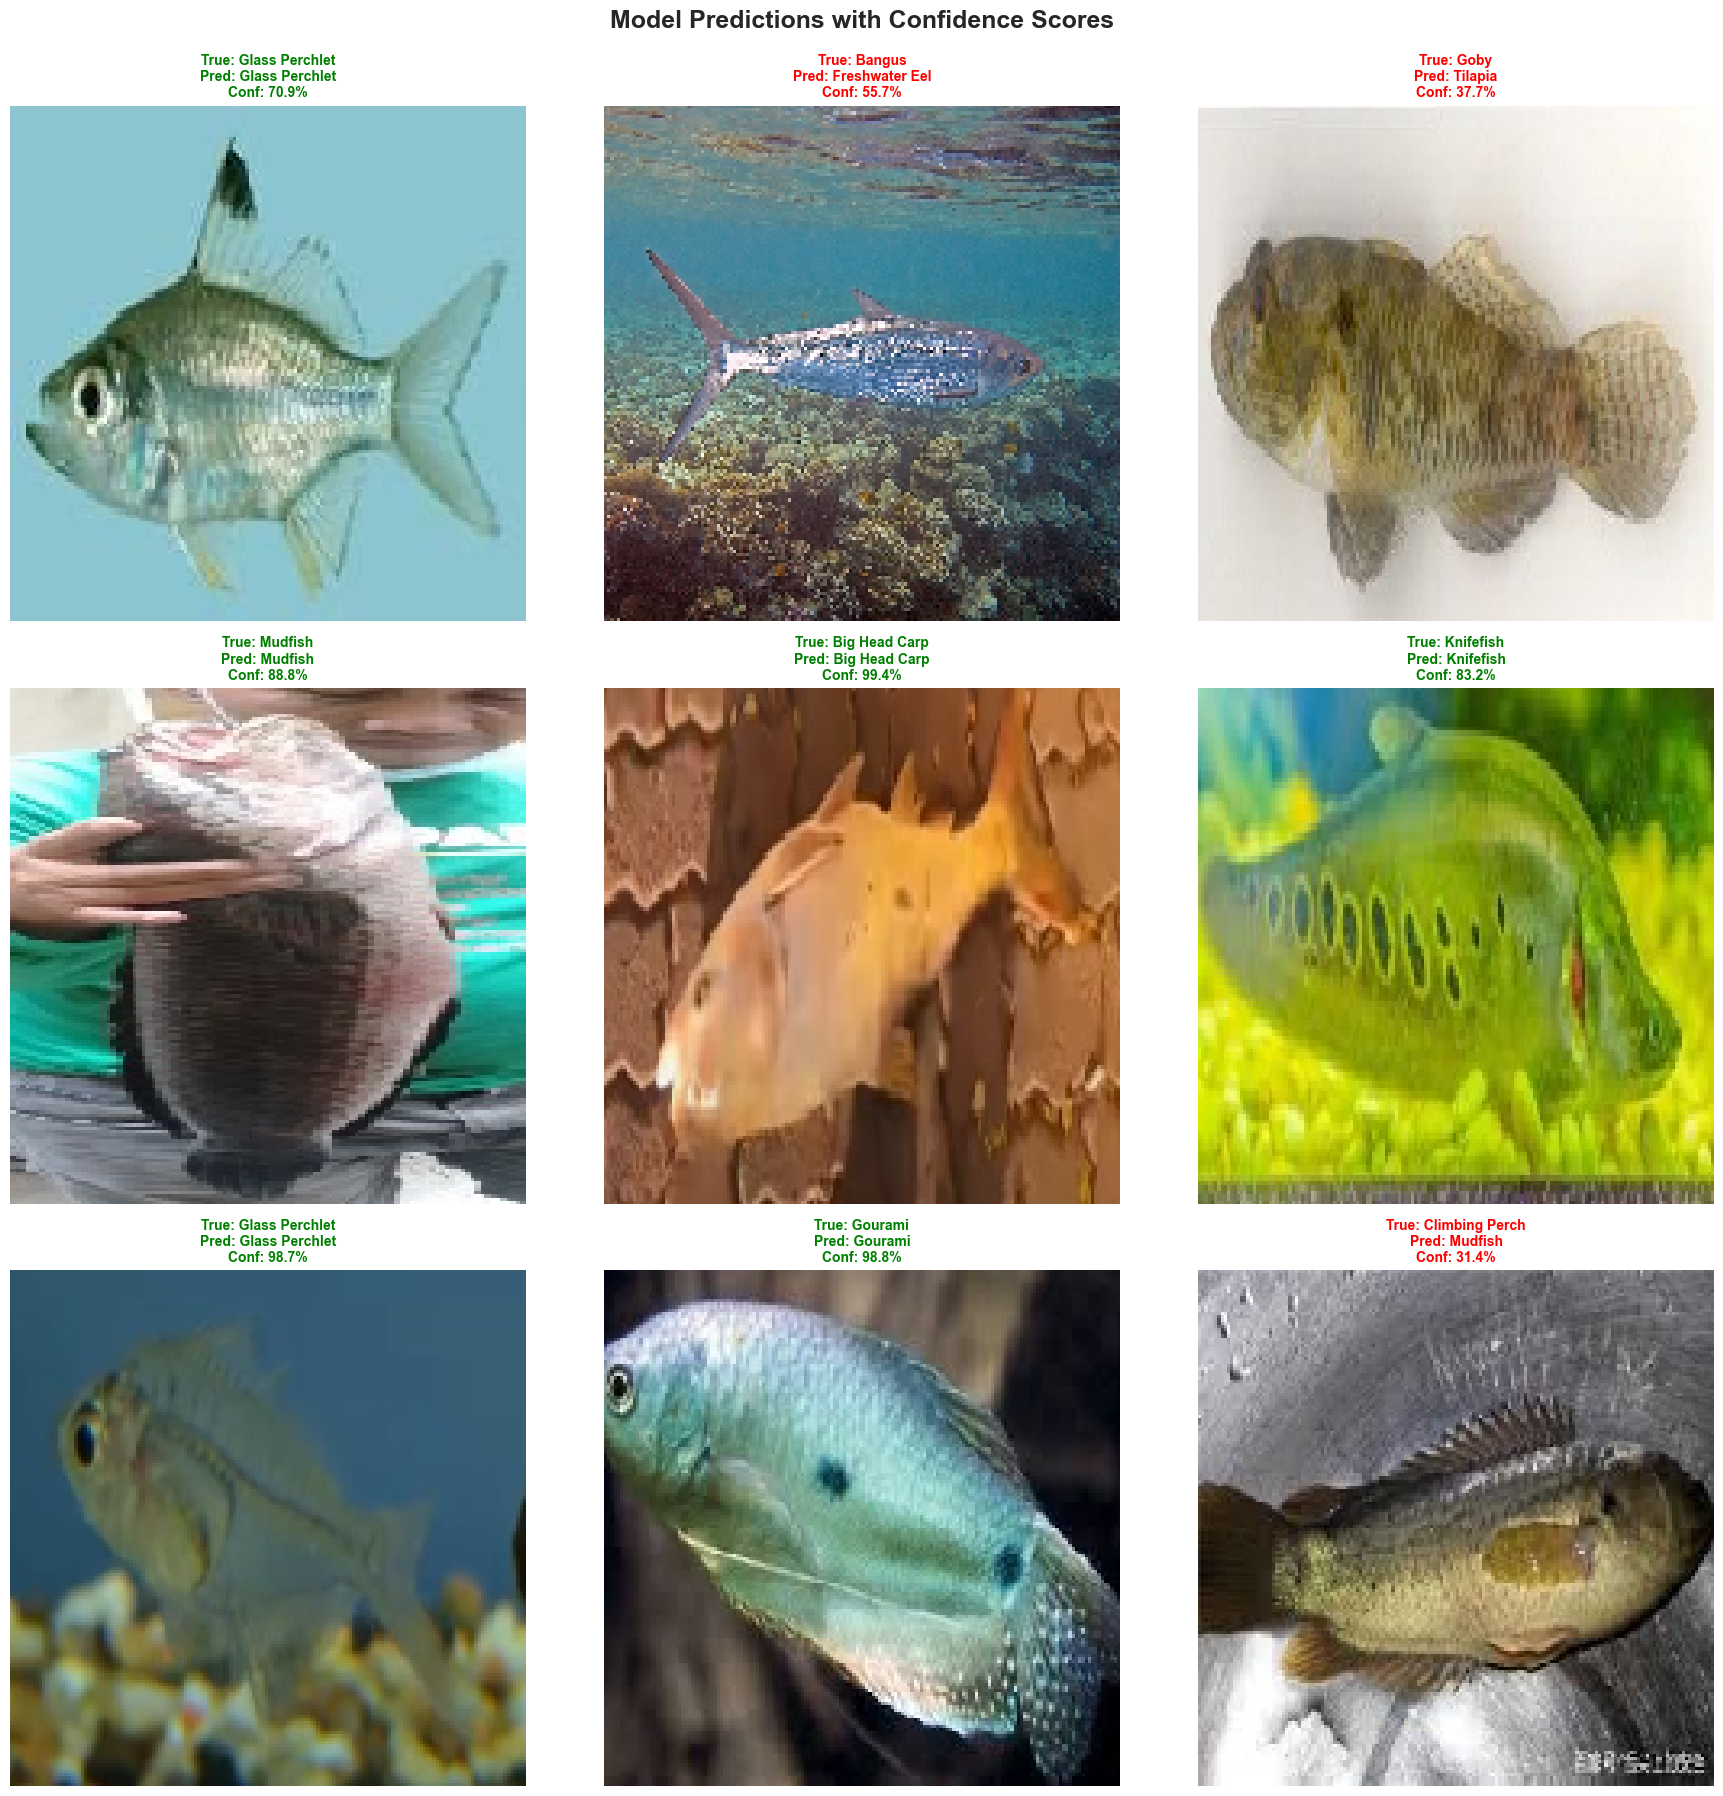


MobileNetV2 Predictions:


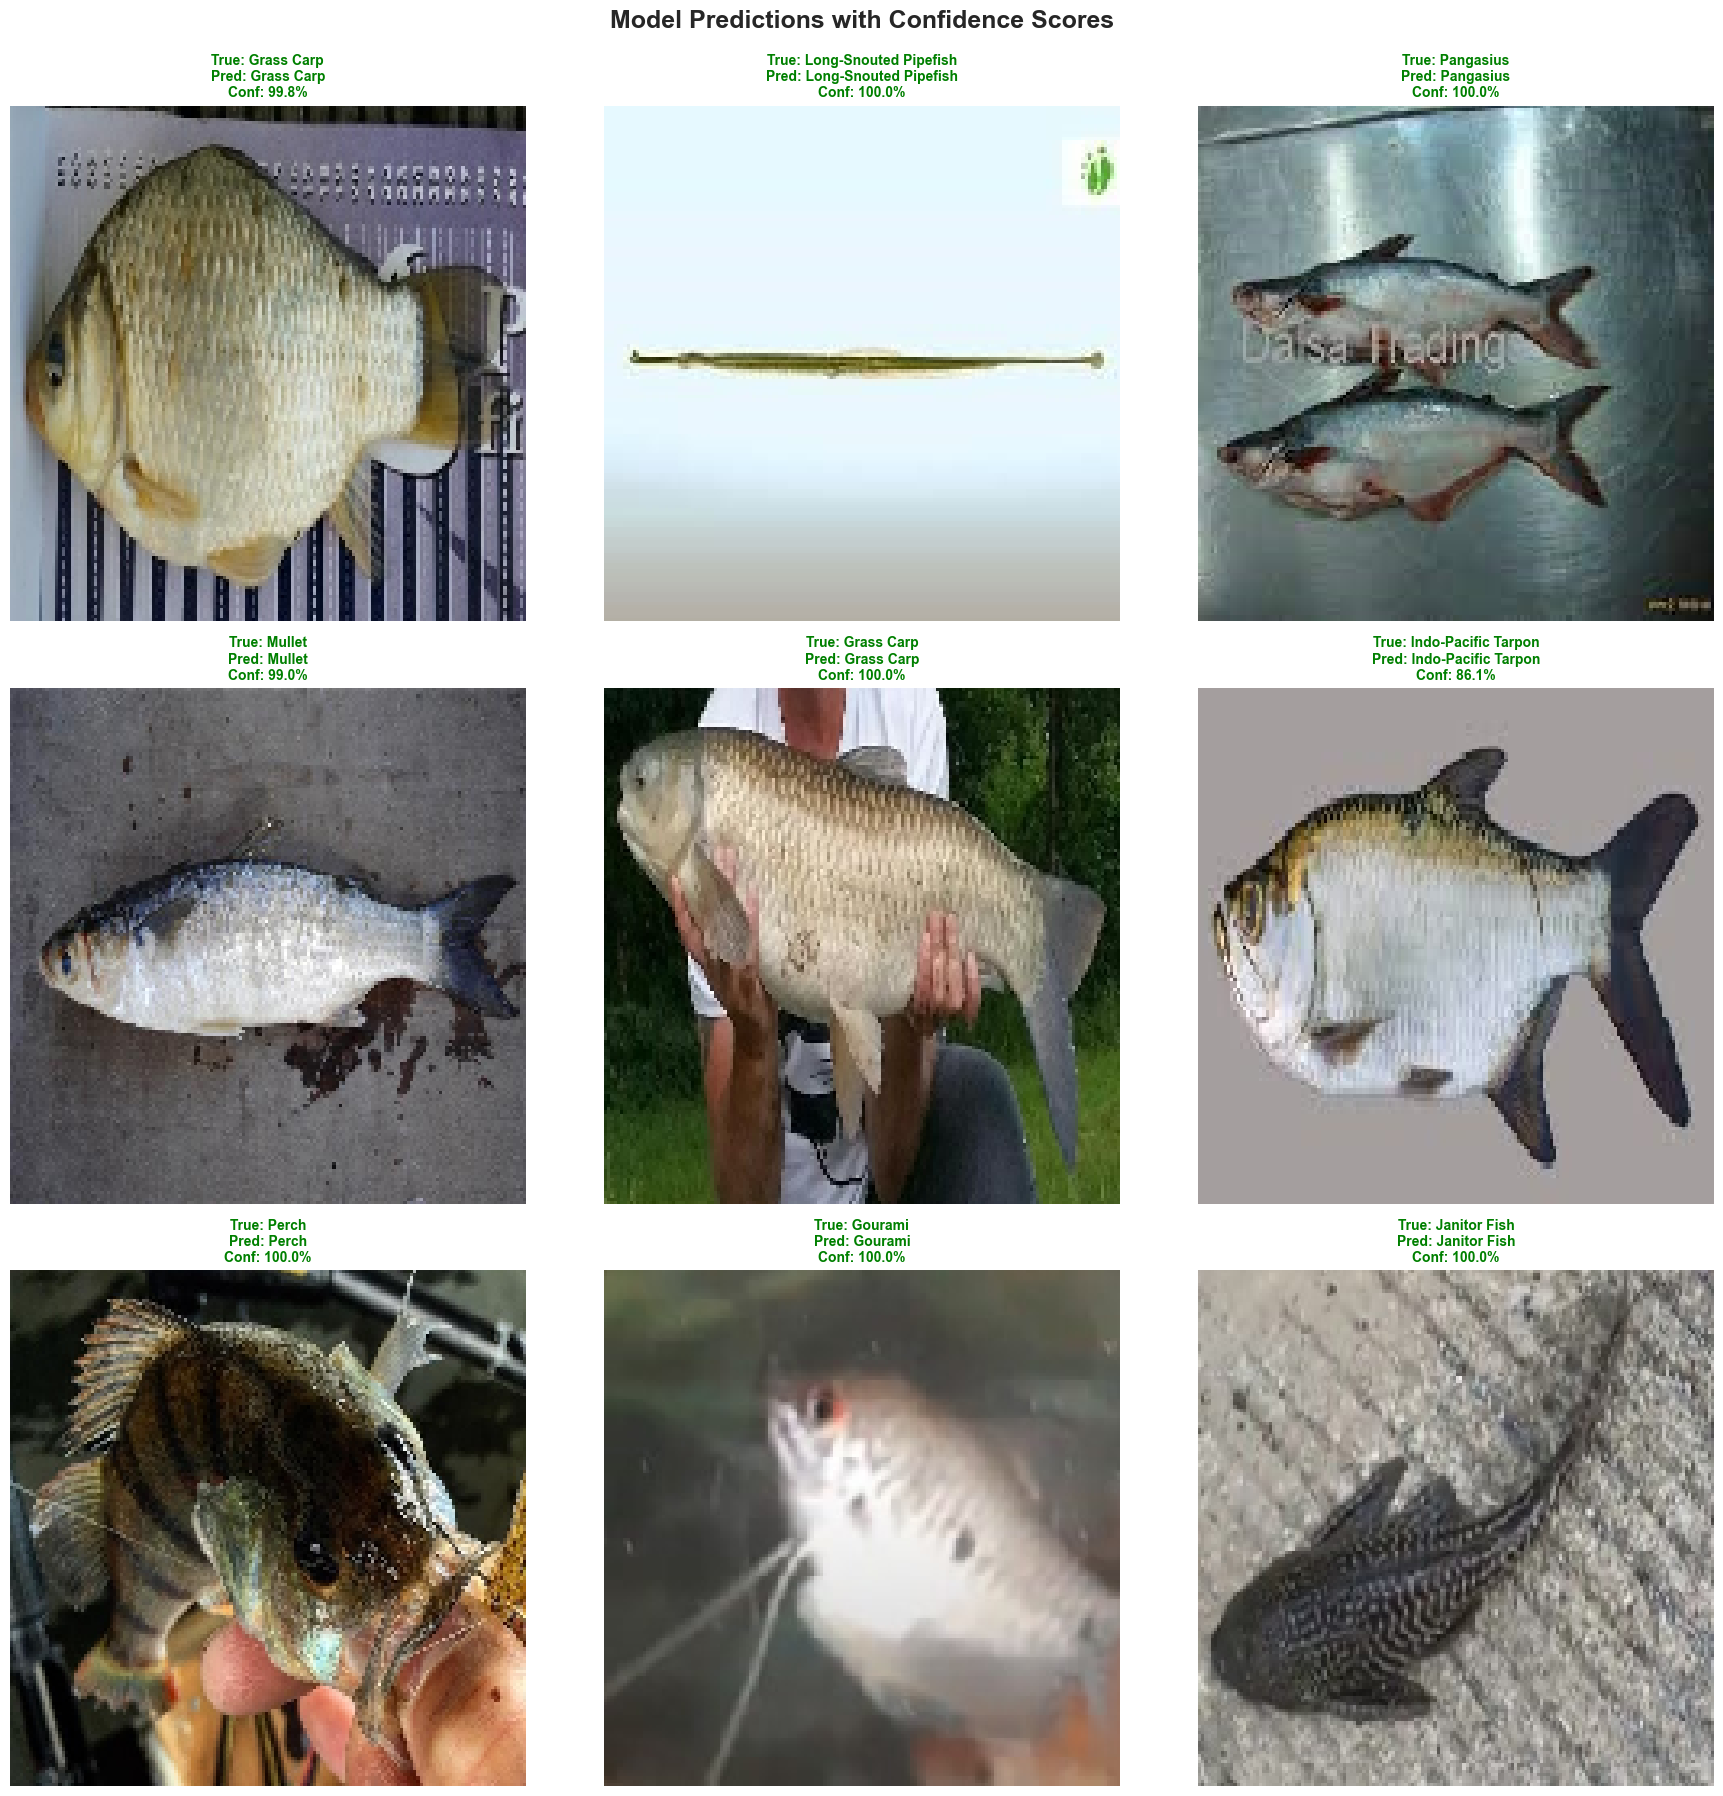

In [55]:
# Visualize predictions with confidence scores
def visualize_predictions(model, num_samples=9):
    """
    Display sample images with predictions and confidence scores.
    
    Args:
        model: Trained model to use for predictions
        num_samples: Number of samples to display
    """
    # Select random test images
    test_images = list(set(
        list(TEST_DIR.glob('*/*.jpg')) + list(TEST_DIR.glob('*/*.JPG')) +
        list(TEST_DIR.glob('*/*.jpeg')) + list(TEST_DIR.glob('*/*.JPEG')) +
        list(TEST_DIR.glob('*/*.png')) + list(TEST_DIR.glob('*/*.PNG')) +
        list(TEST_DIR.glob('*/*.gif')) + list(TEST_DIR.glob('*/*.GIF')) +
        list(TEST_DIR.glob('*/*.webp')) + list(TEST_DIR.glob('*/*.WEBP'))
    ))
    selected_images = np.random.choice(test_images, size=min(num_samples, len(test_images)), replace=False)
    
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(18, 18))
    fig.suptitle('Model Predictions with Confidence Scores', fontsize=18, fontweight='bold', y=0.995)
    
    for i, img_path in enumerate(selected_images):
        row = i // grid_size
        col = i % grid_size
        ax = axes[row, col] if grid_size > 1 else axes
        
        # Load and preprocess image
        img = load_img(img_path, target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        img_array_batch = np.expand_dims(img_array, axis=0)
        
        # Get prediction
        prediction = model.predict(img_array_batch, verbose=0)[0]
        predicted_class_idx = np.argmax(prediction)
        predicted_class = CLASS_NAMES[predicted_class_idx]
        confidence = prediction[predicted_class_idx] * 100
        
        # True label
        true_class = img_path.parent.name
        
        # Display image
        ax.imshow(img)
        
        # Set title with prediction
        color = 'green' if predicted_class == true_class else 'red'
        title = f'True: {true_class}\nPred: {predicted_class}\nConf: {confidence:.1f}%'
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')
        ax.axis('off')
    
    # Hide empty subplots
    for i in range(num_samples, grid_size * grid_size):
        row = i // grid_size
        col = i % grid_size
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize predictions from both models
print("Custom CNN Predictions:")
visualize_predictions(model_custom, num_samples=9)

print("\nMobileNetV2 Predictions:")
visualize_predictions(model_mobilenet, num_samples=9)

## 25. Grad-CAM Visualization (Class Activation Maps)

Grad-CAM helps us understand which parts of the image the model focuses on when making predictions.

Generating Grad-CAM visualizations using layer: conv2d_5


Sample 1: Knifefish
⚠️  Shape mismatch: original (160, 3) vs heatmap (160, 160, 3)


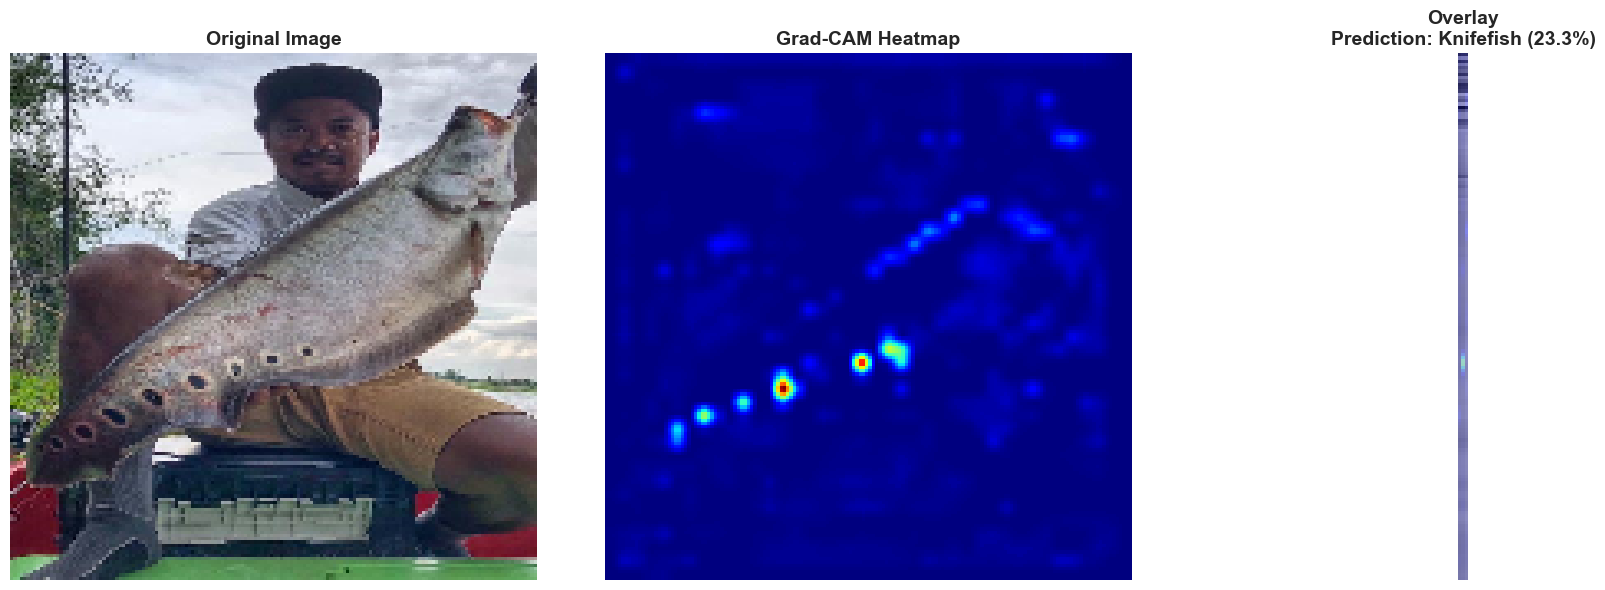

✓ Successfully generated Grad-CAM for Picture188.jpg

Sample 2: Mudfish
⚠️  Shape mismatch: original (160, 3) vs heatmap (160, 160, 3)


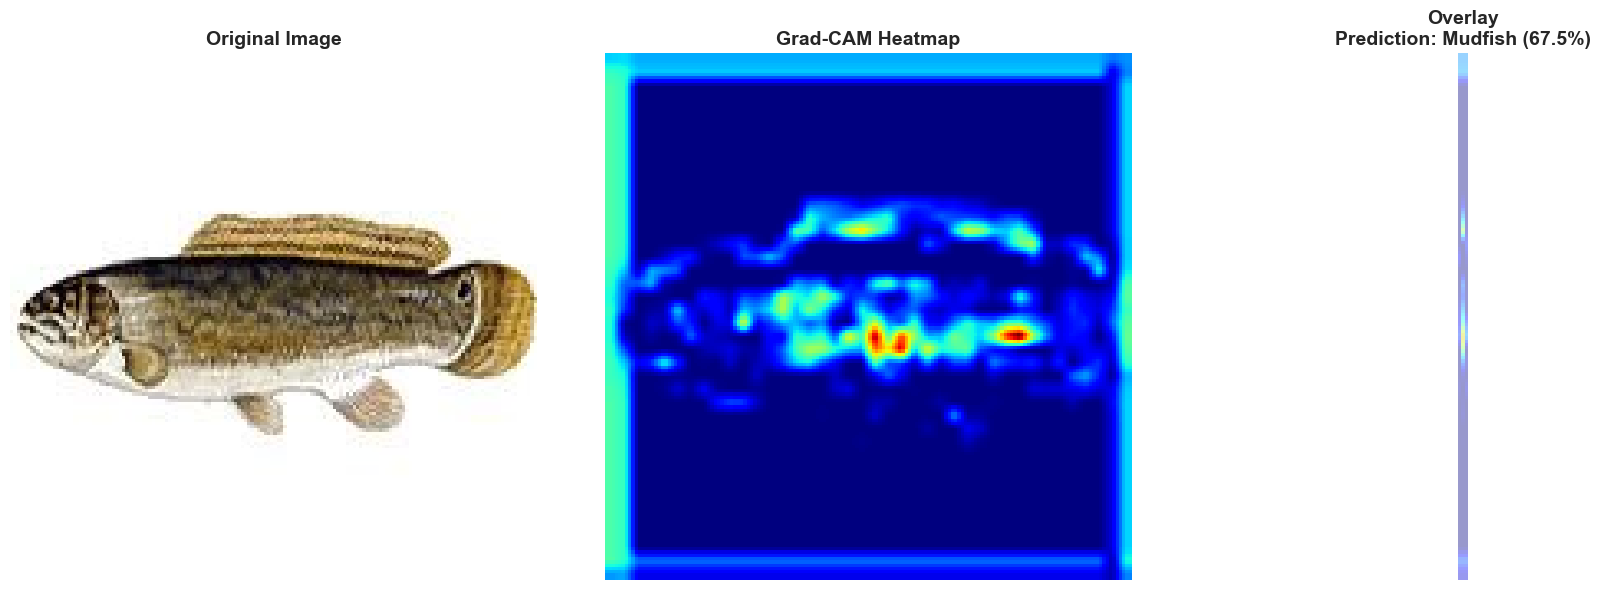

✓ Successfully generated Grad-CAM for Mudfish 012.jpg

Sample 3: Grass Carp
⚠️  Shape mismatch: original (160, 3) vs heatmap (160, 160, 3)


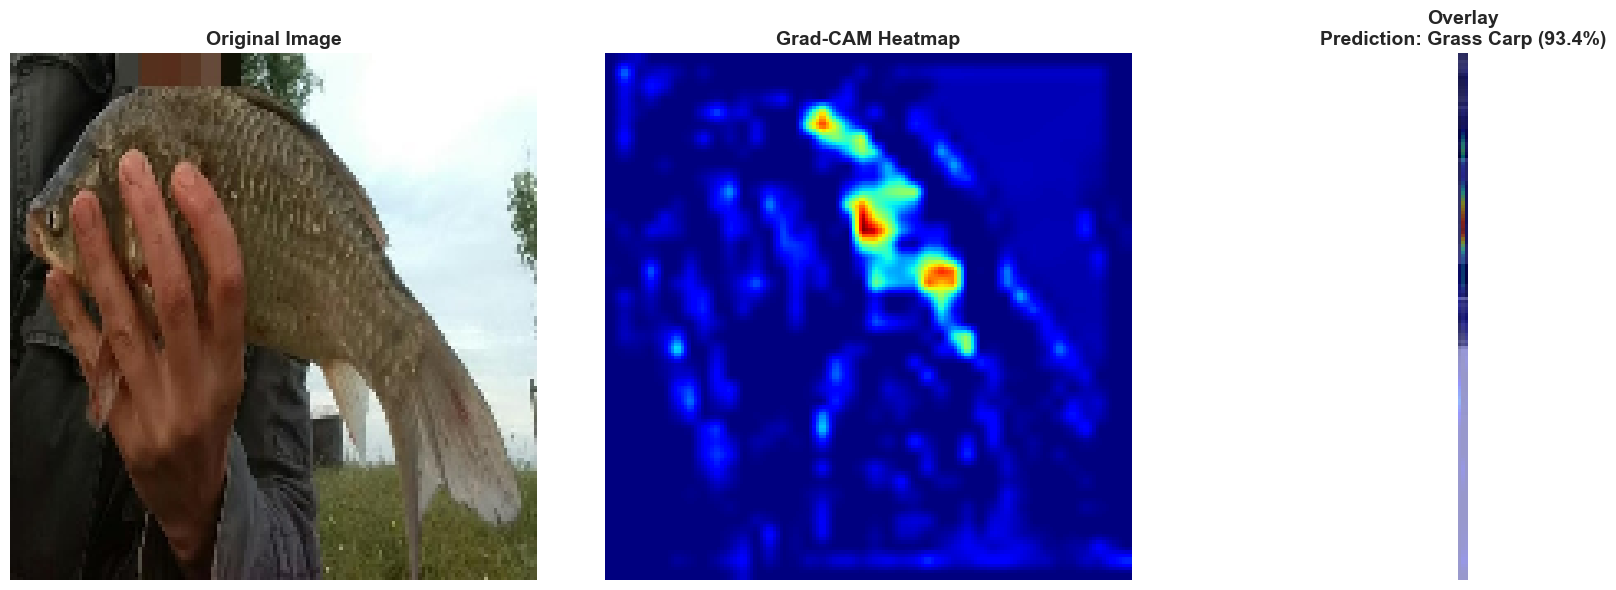

✓ Successfully generated Grad-CAM for 9833c483-8b3a-4050-8934-92d791fa968f-0mm.jpg


In [58]:
# Import cv2 for better image resizing
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for visualizing model attention.
    
    Args:
        img_array: Preprocessed image array
        model: Trained model
        last_conv_layer_name: Name of the last convolutional layer
        pred_index: Class index to visualize (None = predicted class)
    """
    try:
        # Verify layer exists
        last_conv_layer = model.get_layer(last_conv_layer_name)
    except ValueError as e:
        raise ValueError(f"Layer '{last_conv_layer_name}' not found in model. Error: {e}")
    
    # Create a model that outputs the last conv layer and predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )
    
    # Compute gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Check if gradients are None
    if grads is None:
        raise RuntimeError(
            f"Gradients are None! Layer '{last_conv_layer_name}' might be frozen or disconnected."
        )
    
    # Pool gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the channels by the gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize heatmap to [0, 1]
    heatmap = tf.maximum(heatmap, 0)  # ReLU
    if tf.reduce_max(heatmap) > 0:  # Avoid division by zero
        heatmap = heatmap / tf.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(img_path, model, last_conv_layer_name):
    """
    Display original image with Grad-CAM overlay (Fixed version).
    """
    try:
        # Load and preprocess image
        img = load_img(img_path, target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        img_array_batch = np.expand_dims(img_array, axis=0)
        
        # Get prediction
        preds = model.predict(img_array_batch, verbose=0)
        pred_class_idx = np.argmax(preds[0])
        pred_class = CLASS_NAMES[pred_class_idx]
        confidence = preds[0][pred_class_idx] * 100
        
        # Generate heatmap
        heatmap = make_gradcam_heatmap(img_array_batch, model, last_conv_layer_name)
        
        # Resize heatmap to match image size using cv2 (FIXED!)
        # heatmap is 2D (e.g., 40x40), need to resize to (160x160)
        heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
        
        # Normalize to 0-255 range
        heatmap_resized = np.uint8(255 * heatmap_resized)
        
        # Apply colormap using cv2
        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        
        # Create superimposed image - ENSURE SAME SHAPE AND TYPE
        original_img = np.uint8(img_array[0] * 255)
        
        # Make sure both images have same shape
        if original_img.shape != heatmap_colored.shape:
            print(f"⚠️  Shape mismatch: original {original_img.shape} vs heatmap {heatmap_colored.shape}")
            # Resize heatmap_colored to match original_img if needed
            heatmap_colored = cv2.resize(heatmap_colored, (original_img.shape[1], original_img.shape[0]))
        
        # Ensure both are 3-channel images
        if len(original_img.shape) == 2:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
        elif original_img.shape[2] == 4:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
        
        superimposed = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)
        
        # Display
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        axes[0].imshow(img)
        axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(heatmap_resized, cmap='jet')
        axes[1].set_title('Grad-CAM Heatmap', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(superimposed)
        axes[2].set_title(f'Overlay\nPrediction: {pred_class} ({confidence:.1f}%)', 
                         fontsize=14, fontweight='bold')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Successfully generated Grad-CAM for {img_path.name}")
        
    except Exception as e:
        print(f"❌ Error generating Grad-CAM for {img_path.name}: {str(e)}")
        import traceback
        traceback.print_exc()

# Get last convolutional layer for custom CNN
custom_conv_layers = [layer.name for layer in model_custom.layers if 'conv' in layer.name.lower()]
last_conv_custom = custom_conv_layers[-1]

# Select random test images
test_images = list(set(
    list(TEST_DIR.glob('*/*.jpg')) + list(TEST_DIR.glob('*/*.JPG')) +
    list(TEST_DIR.glob('*/*.jpeg')) + list(TEST_DIR.glob('*/*.JPEG')) +
    list(TEST_DIR.glob('*/*.png')) + list(TEST_DIR.glob('*/*.PNG')) +
    list(TEST_DIR.glob('*/*.gif')) + list(TEST_DIR.glob('*/*.GIF')) +
    list(TEST_DIR.glob('*/*.webp')) + list(TEST_DIR.glob('*/*.WEBP'))
))
sample_images = np.random.choice(test_images, size=3, replace=False)

print(f"Generating Grad-CAM visualizations using layer: {last_conv_custom}\n")

for i, img_path in enumerate(sample_images):
    print(f"\nSample {i+1}: {img_path.parent.name}")
    display_gradcam(img_path, model_custom, last_conv_custom)

## 26. Summary and Conclusions

### Key Achievements

In this comprehensive CNN assignment, we successfully:

1. **Dataset Exploration & Preprocessing**
   - Analyzed a dataset of 31 fish species with train/val/test splits
   - Identified and quantified class imbalance
   - Applied data normalization and augmentation techniques

2. **Data Augmentation**
   - Implemented various augmentation strategies: rotation, shifting, shearing, zooming, and flipping
   - Enhanced model generalization and robustness

3. **Class Imbalance Handling**
   - Computed class weights using sklearn
   - Applied weights during training to balance learning across all species

4. **Custom CNN Architecture**
   - Designed a CNN from scratch with 4 convolutional blocks
   - Incorporated batch normalization and dropout for regularization
   - Used global average pooling to reduce parameters

5. **Transfer Learning**
   - Applied MobileNetV2 pre-trained on ImageNet
   - Fine-tuned with custom classification head
   - Leveraged learned features for improved performance

6. **Model Evaluation**
   - Evaluated using accuracy, top-5 accuracy, and loss metrics
   - Generated confusion matrices for detailed analysis
   - Created classification reports with precision, recall, and F1-scores

7. **CNN Interpretability**
   - Visualized convolutional filters to understand low-level features
   - Examined feature maps from different layers
   - Implemented Grad-CAM for attention visualization
   - Analyzed model predictions with confidence scores

### Key Insights

- **Feature Learning**: Early layers learn edge and texture detectors, while deeper layers learn complex patterns
- **Transfer Learning Benefits**: Pre-trained models often achieve better performance with less training time
- **Class Imbalance**: Using class weights significantly improves performance on minority classes
- **Data Augmentation**: Essential for preventing overfitting and improving generalization

